# 📊 Projet ML Retail — Analyse Exploratoire, Clustering KMeans & Évaluation des Modèles

**Objectif :** Prédire le churn client (résiliation) à partir de données comportementales retail.  
**Dataset :** 4 372 clients × 52 features  
**Modèle final :** XGBoost optimisé (Optuna) — AUC-ROC : 0.8948 | F1 : 0.7372

---
## Table des matières
1. [Chargement & Nettoyage](#1)
2. [Analyse Exploratoire (EDA)](#2)
3. [Feature Engineering](#3)
4. [Clustering KMeans](#4)
5. [Entraînement des modèles](#5)
6. [Courbes ROC, Precision-Recall](#6)
7. [Matrices de confusion](#7)
8. [Feature Importance](#8)
9. [Synthèse & Interprétation des métriques](#9)


## 1. Chargement & Nettoyage des données <a id='1'></a>

In [2]:
!pip install pandas numpy scikit-learn xgboost optuna joblib matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, io, re
from sklearn.preprocessing import StandardScaler, RobustScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, roc_auc_score, silhouette_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
PALETTE = ['#2563EB', '#DC2626']
RANDOM_STATE = 42
print("✅ Librairies importées")


✅ Librairies importées


In [4]:
# ── Chargement avec résolution des conflits Git ──
def load_clean_csv(path):
    with open(path, encoding='utf-8') as f:
        lines = f.readlines()
    clean, in_other = [], False
    for line in lines:
        if line.startswith('<<<<<<<'):  continue
        elif line.startswith('======='): in_other = True;  continue
        elif line.startswith('>>>>>>>'): in_other = False; continue
        if not in_other: clean.append(line)
    return pd.read_csv(io.StringIO(''.join(clean)))

df_raw = load_clean_csv('data/raw/retail_customers_COMPLETE_CATEGORICAL.csv')
print(f"✅ Dataset chargé : {df_raw.shape[0]} lignes × {df_raw.shape[1]} colonnes")
df_raw.head(3)


✅ Dataset chargé : 4372 lignes × 52 colonnes


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,...,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,...,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,...,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,...,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0


In [5]:
# ── Informations générales ──
print("=== TYPES DE COLONNES ===")
print(df_raw.dtypes.value_counts())
print(f"\n=== VALEURS MANQUANTES ===")
missing = df_raw.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))
print(f"\n=== DOUBLONS === {df_raw.duplicated().sum()}")


=== TYPES DE COLONNES ===
int64      20
str        18
float64    14
Name: count, dtype: int64

=== VALEURS MANQUANTES ===
Age                        1311
AvgDaysBetweenPurchases      79
dtype: int64

=== DOUBLONS === 0


## 2. Analyse Exploratoire (EDA) <a id='2'></a>

### 2.1 Distribution de la cible (Churn)
> Le déséquilibre des classes est un facteur critique : ~67 % non-churners vs ~33 % churners.  
> Sans correction (SMOTE ou `class_weight`), le modèle apprend simplement à toujours prédire 0.


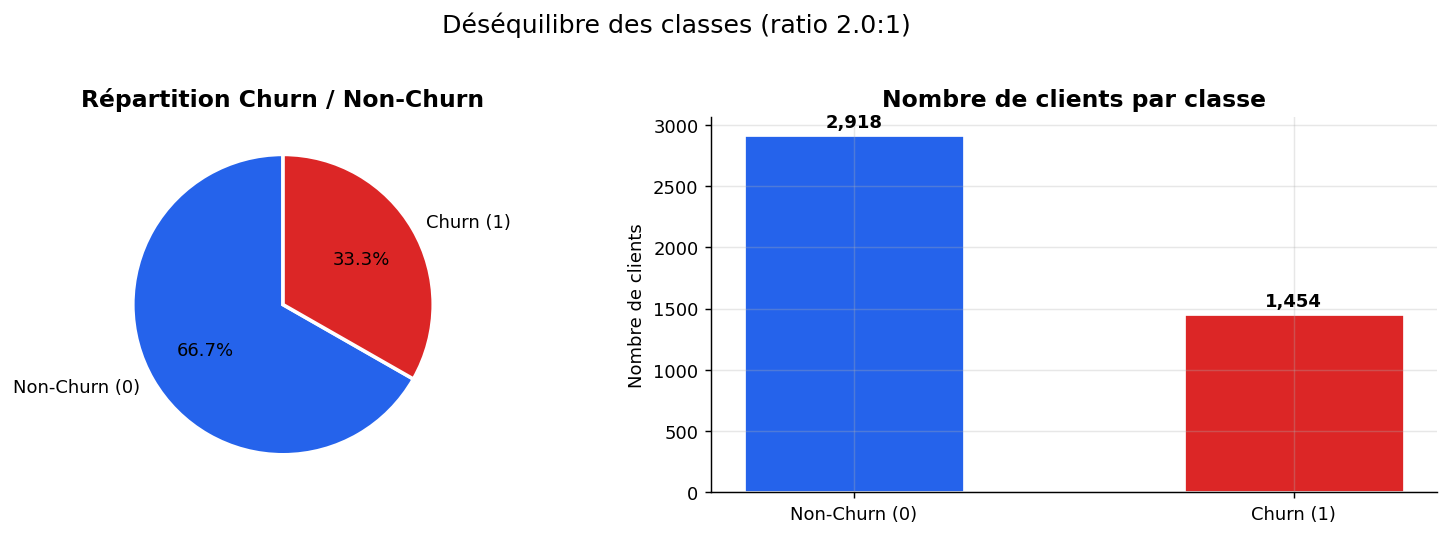

Classe 0 (Non-Churn) : 2,918 (66.7%)
Classe 1 (Churn)     : 1,454 (33.3%)
Ratio déséquilibre   : 2.01:1


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Camembert
churn_counts = df_raw['Churn'].value_counts()
axes[0].pie(
    churn_counts, labels=['Non-Churn (0)', 'Churn (1)'],
    autopct='%1.1f%%', colors=PALETTE, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Répartition Churn / Non-Churn', fontsize=13, fontweight='bold')

# Barplot
bars = axes[1].bar(['Non-Churn (0)', 'Churn (1)'], churn_counts.values,
                    color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Nombre de clients par classe', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nombre de clients')

plt.suptitle(f'Déséquilibre des classes (ratio {churn_counts[0]/churn_counts[1]:.1f}:1)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_churn_distribution.png', bbox_inches='tight')
plt.show()
print(f"Classe 0 (Non-Churn) : {churn_counts[0]:,} ({churn_counts[0]/len(df_raw)*100:.1f}%)")
print(f"Classe 1 (Churn)     : {churn_counts[1]:,} ({churn_counts[1]/len(df_raw)*100:.1f}%)")
print(f"Ratio déséquilibre   : {churn_counts[0]/churn_counts[1]:.2f}:1")


### 2.2 Distribution des variables numériques clés

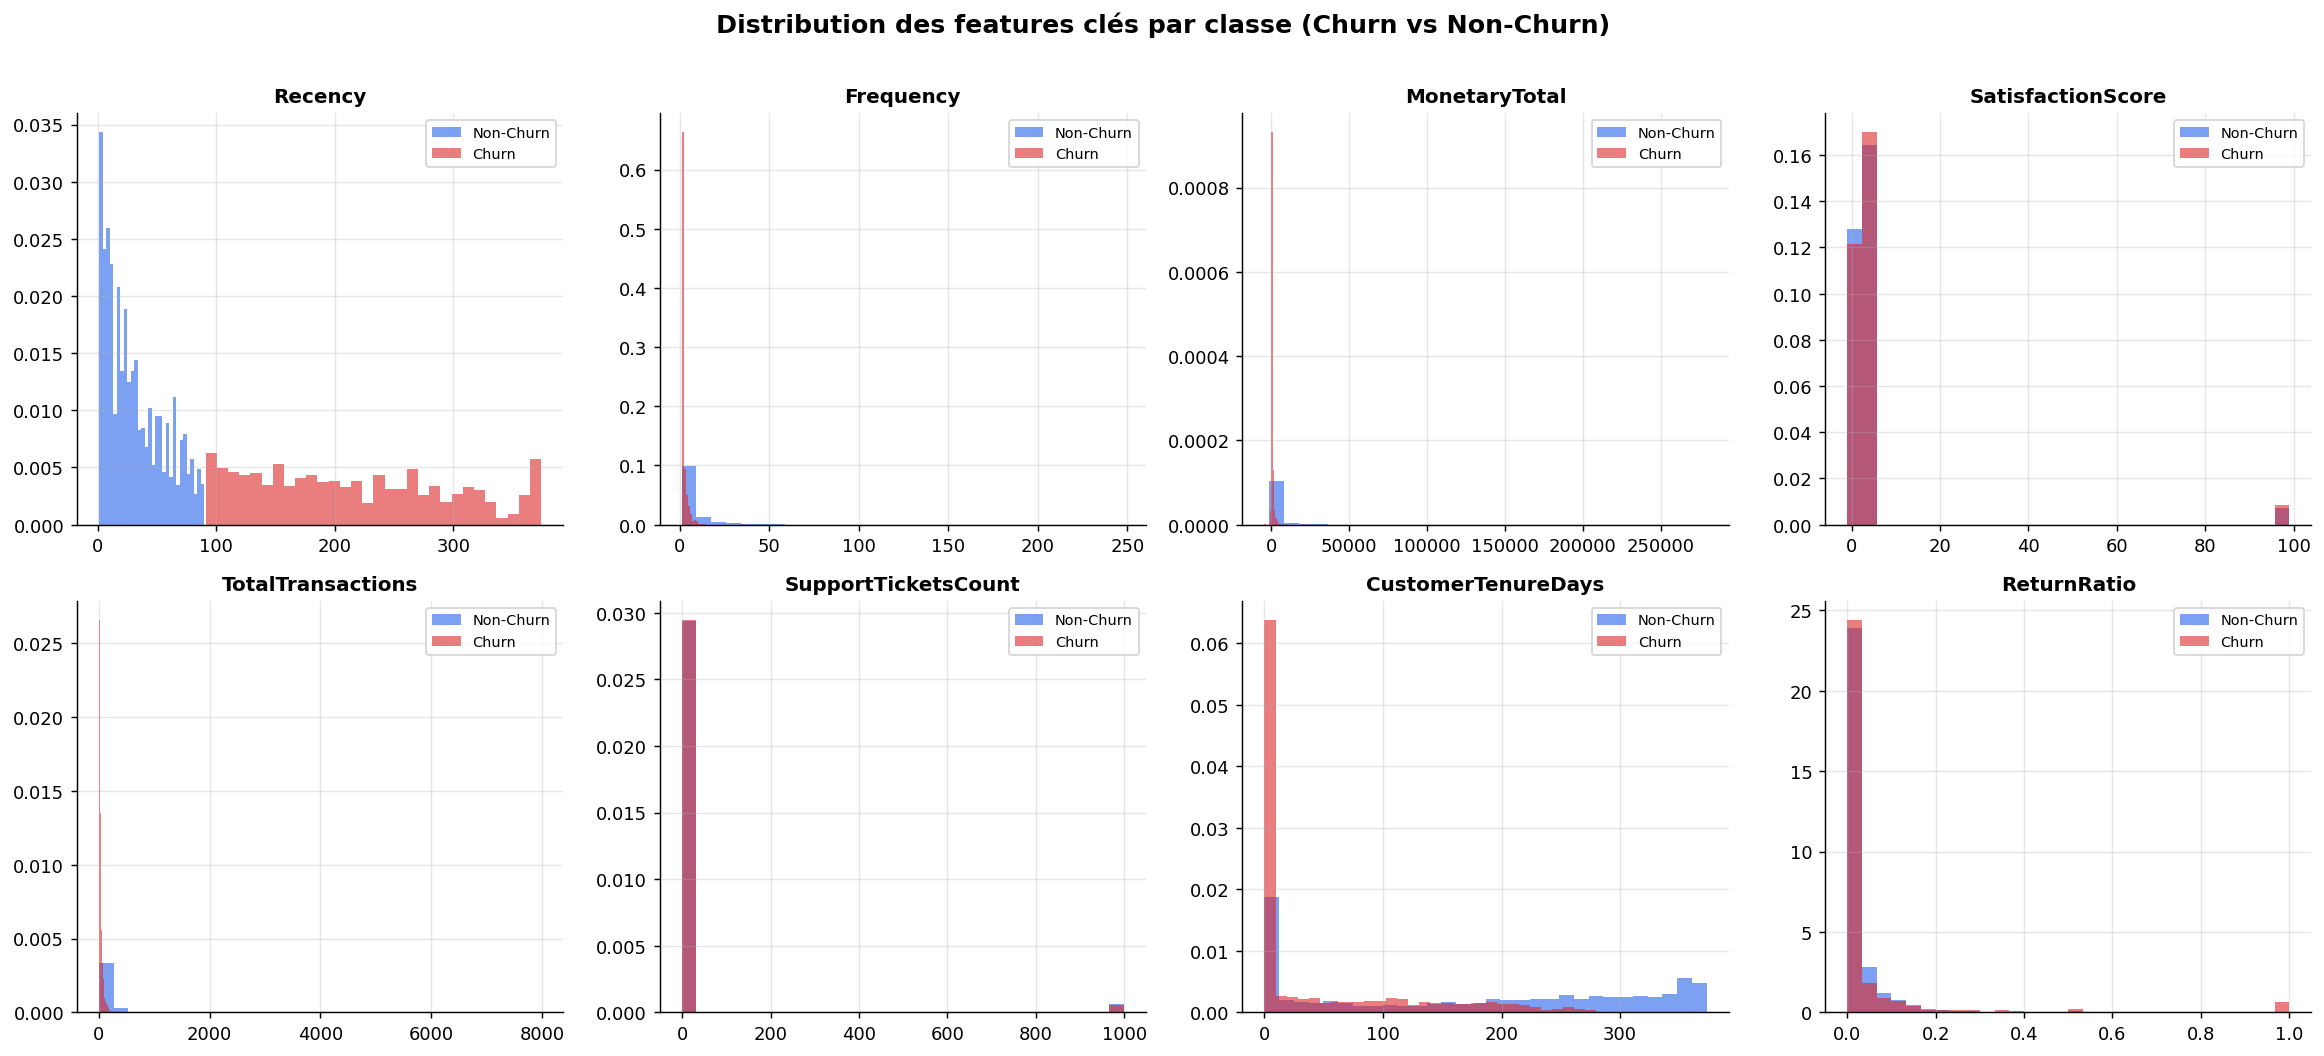

In [7]:
numeric_key = ['Recency', 'Frequency', 'MonetaryTotal', 'SatisfactionScore',
               'TotalTransactions', 'SupportTicketsCount', 'CustomerTenureDays', 'ReturnRatio']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_key):
    if col not in df_raw.columns: continue
    for churn_val, color, label in [(0, PALETTE[0], 'Non-Churn'), (1, PALETTE[1], 'Churn')]:
        data = df_raw[df_raw['Churn'] == churn_val][col].dropna()
        axes[i].hist(data, bins=30, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Distribution des features clés par classe (Churn vs Non-Churn)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()


### 2.3 Corrélation avec le Churn — Variables catégorielles

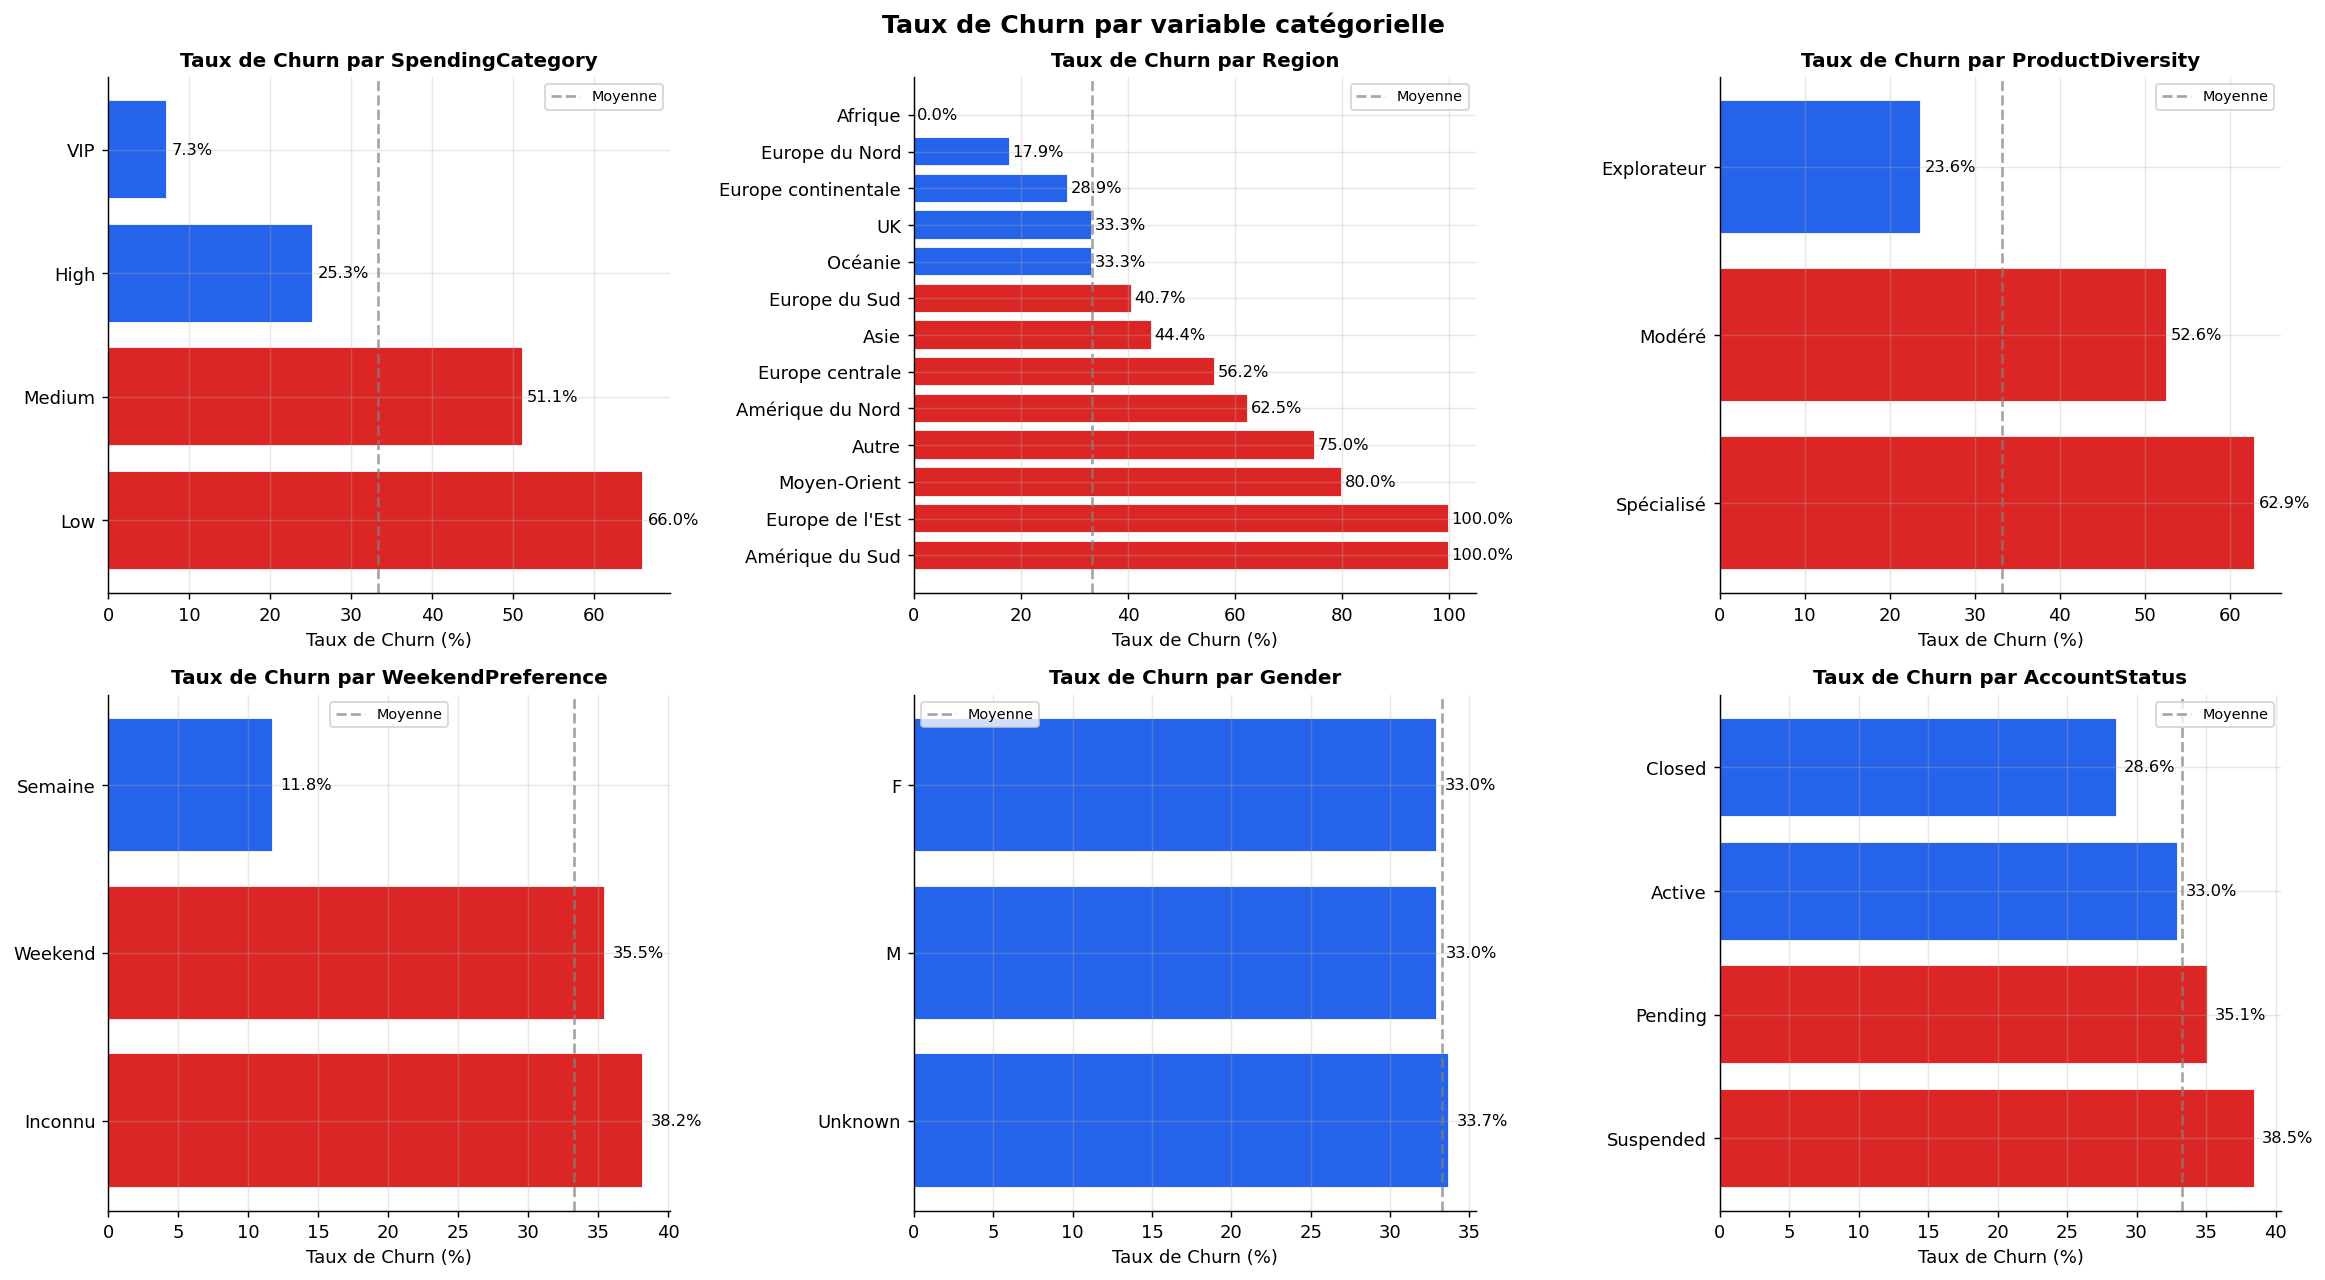

In [8]:
cat_cols_plot = ['SpendingCategory', 'Region', 'ProductDiversity',
                 'WeekendPreference', 'Gender', 'AccountStatus']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
    if col not in df_raw.columns: continue
    ct = df_raw.groupby(col)['Churn'].mean().sort_values(ascending=False)
    counts = df_raw[col].value_counts()
    
    bars = axes[i].barh(ct.index, ct.values * 100,
                        color=[PALETTE[1] if v > 0.35 else PALETTE[0] for v in ct.values],
                        edgecolor='white')
    for bar, val in zip(bars, ct.values):
        axes[i].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val*100:.1f}%', va='center', fontsize=9)
    axes[i].set_title(f'Taux de Churn par {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Taux de Churn (%)')
    axes[i].axvline(df_raw['Churn'].mean()*100, color='gray', linestyle='--', alpha=0.7, label='Moyenne')
    axes[i].legend(fontsize=8)

plt.suptitle('Taux de Churn par variable catégorielle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical_churn.png', bbox_inches='tight')
plt.show()


### 2.4 Matrice de corrélation (features numériques)

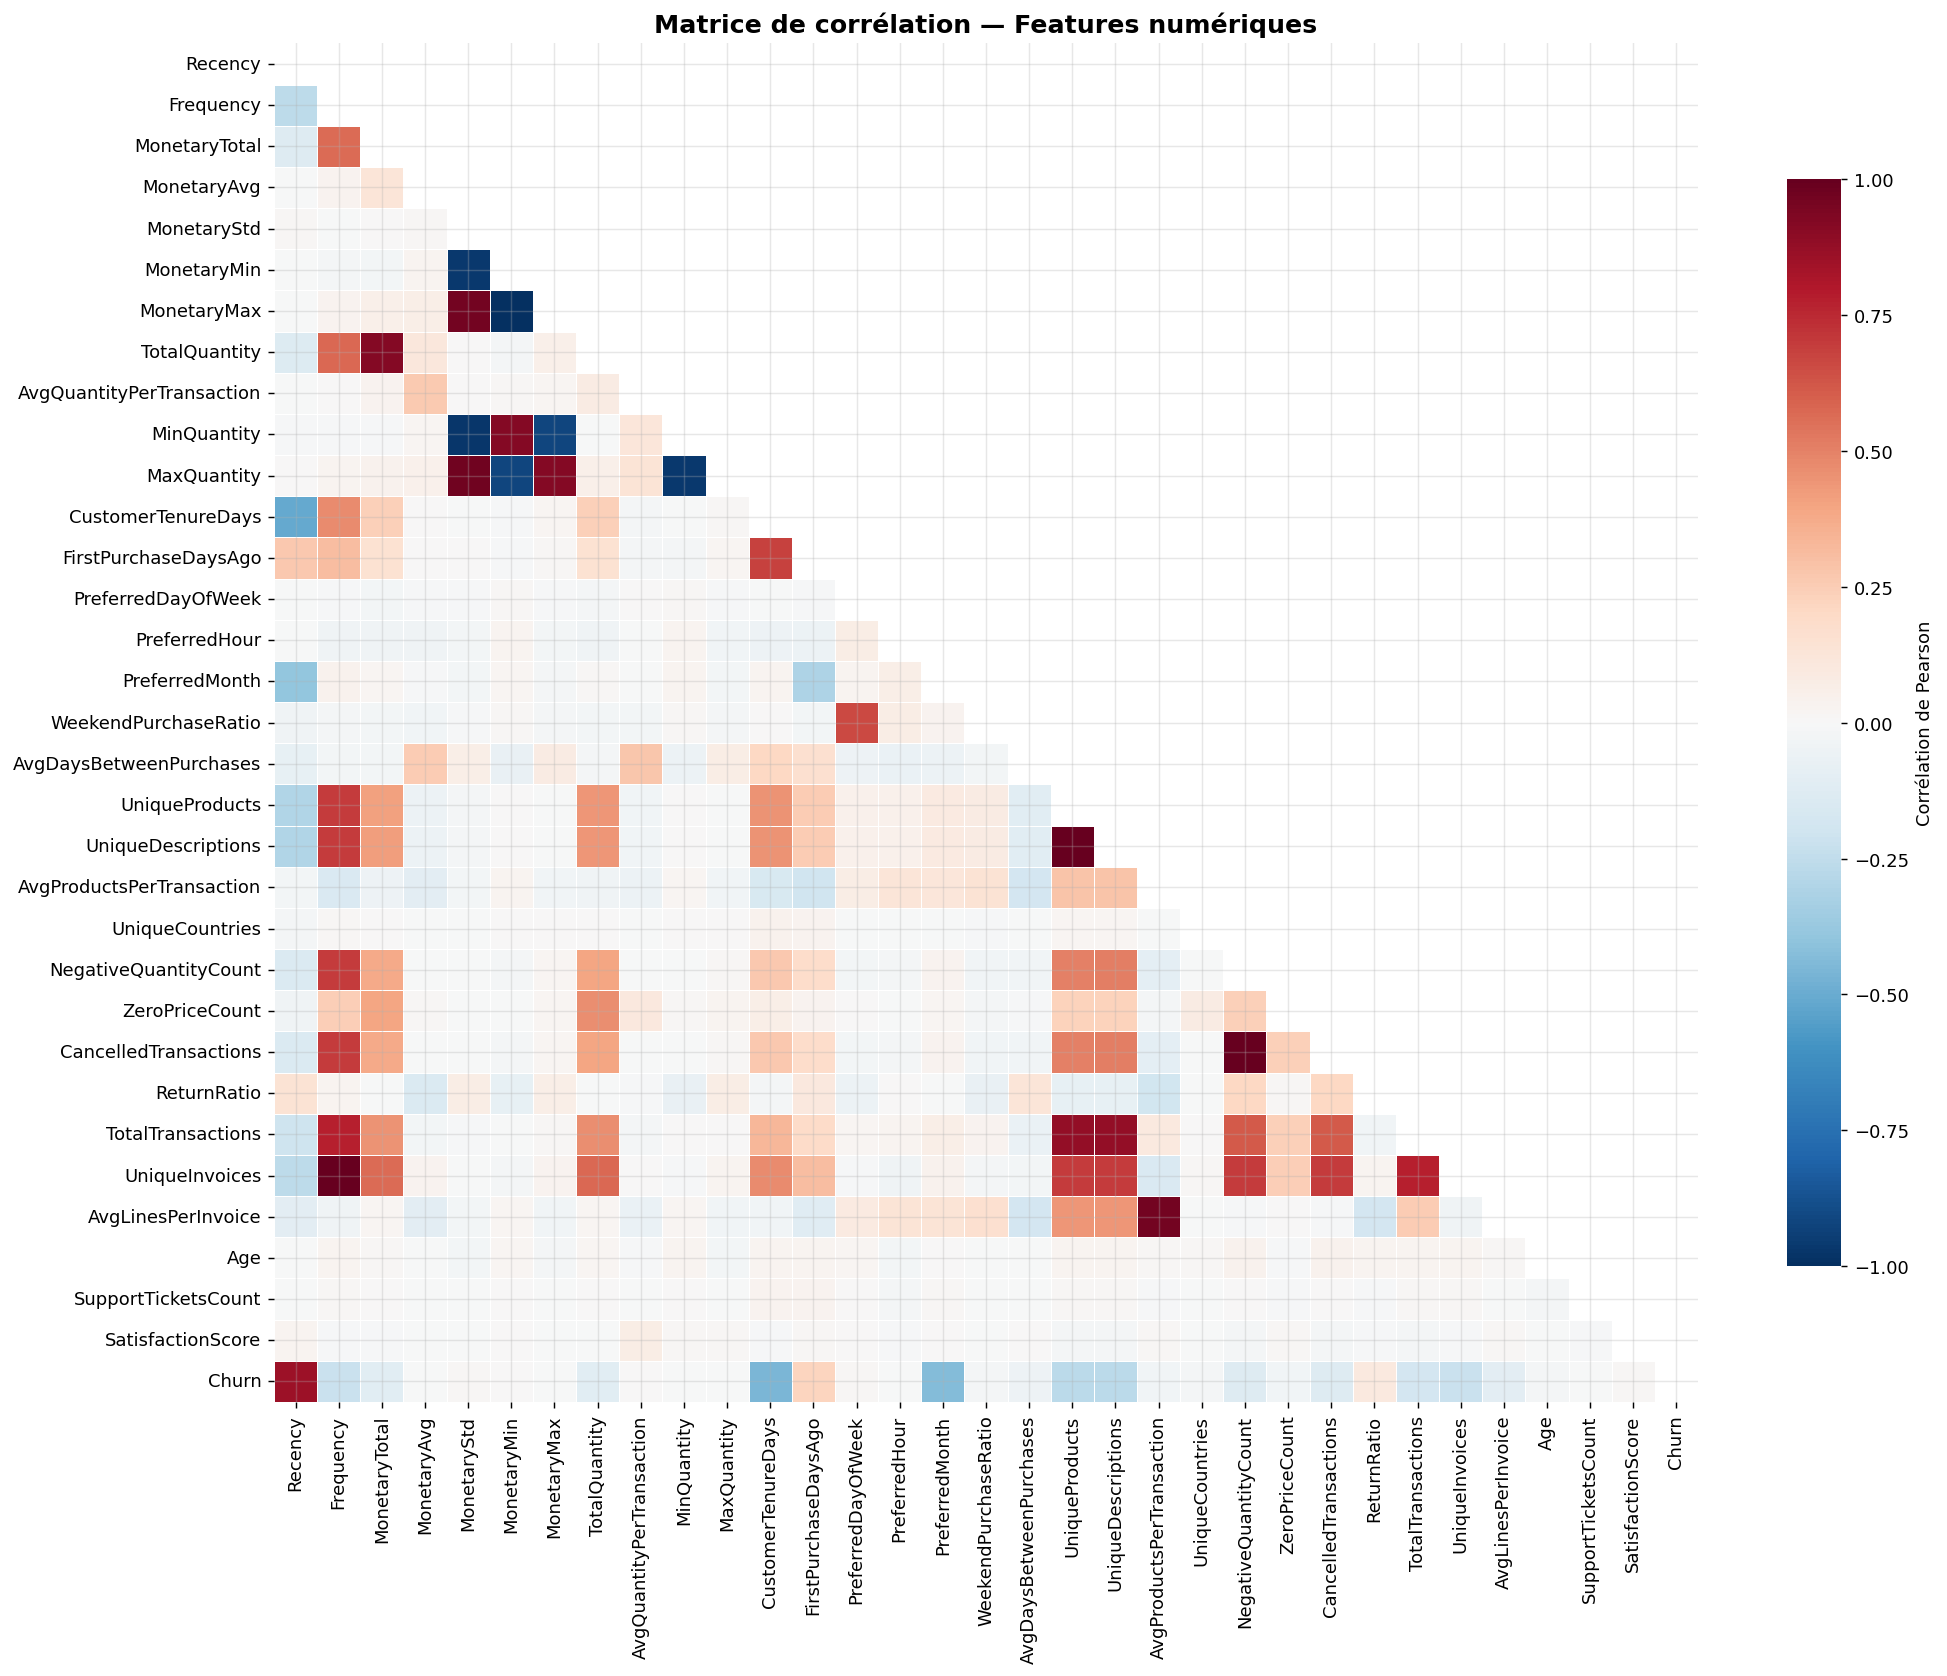


🎯 Top 10 corrélations avec 'Churn' :
Recency                  0.859
CustomerTenureDays       0.453
PreferredMonth           0.431
UniqueDescriptions       0.270
UniqueProducts           0.270
UniqueInvoices           0.223
Frequency                0.223
FirstPurchaseDaysAgo     0.222
TotalTransactions        0.182
NegativeQuantityCount    0.129


In [9]:
numeric_df = df_raw.select_dtypes(include='number').drop(columns=['CustomerID'], errors='ignore')

# Forcer la conversion des colonnes object numériques
for col in ['MonetaryTotal','MonetaryAvg','MonetaryStd','MonetaryMin','MonetaryMax',
            'AvgQuantityPerTransaction','AvgDaysBetweenPurchases','AvgProductsPerTransaction','AvgLinesPerInvoice']:
    if col in df_raw.columns:
        numeric_df[col] = pd.to_numeric(df_raw[col], errors='coerce')

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            cbar_kws={'shrink': 0.8, 'label': 'Corrélation de Pearson'})
ax.set_title('Matrice de corrélation — Features numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_matrix.png', bbox_inches='tight')
plt.show()

# Top corrélations avec Churn
print("\n🎯 Top 10 corrélations avec 'Churn' :")
churn_corr = corr['Churn'].drop('Churn').abs().sort_values(ascending=False).head(10)
print(churn_corr.round(3).to_string())


### 2.5 Boxplots — RFM par Churn

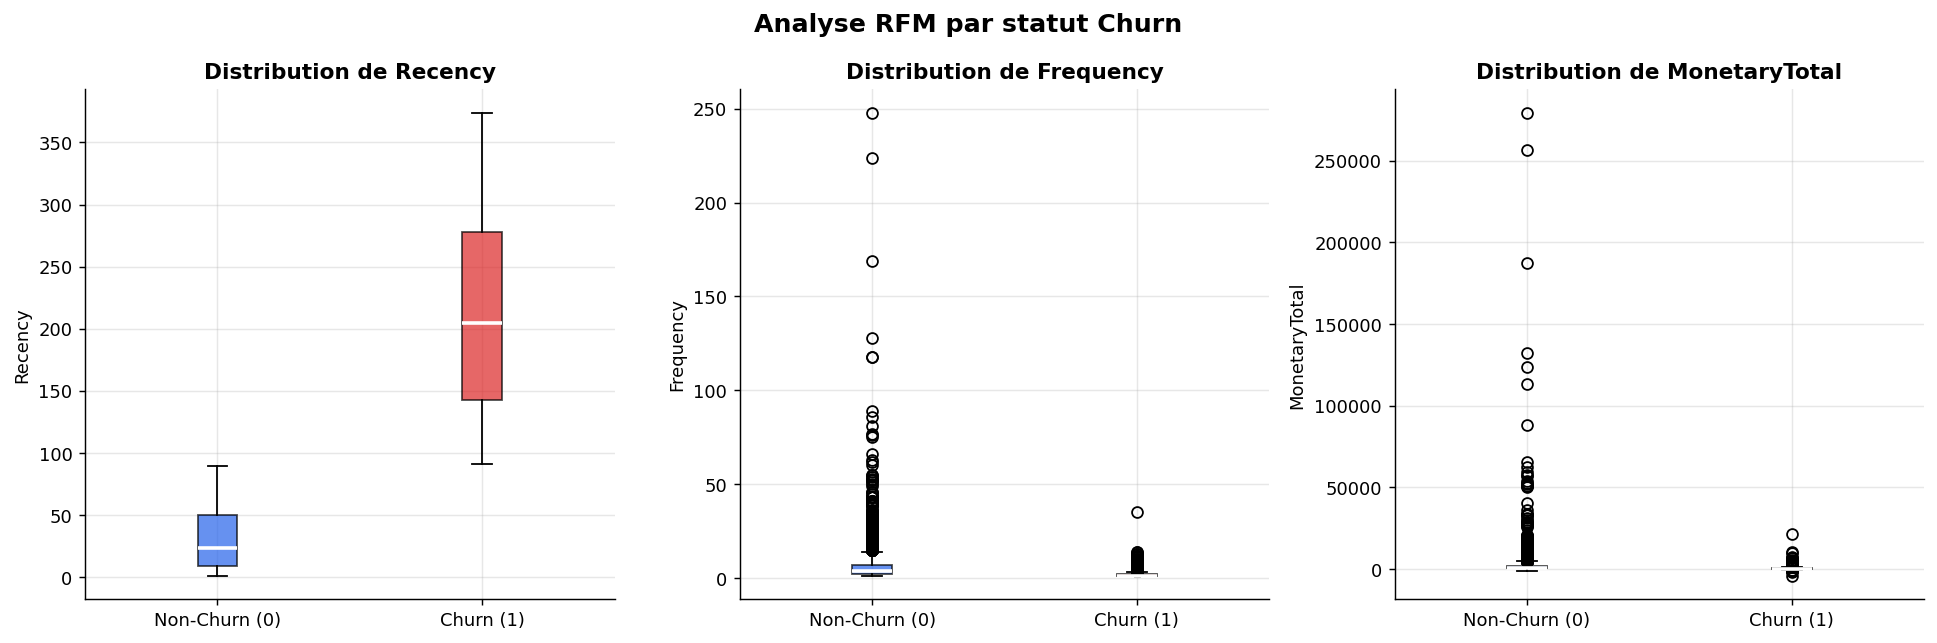

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
rfm_cols = ['Recency', 'Frequency', 'MonetaryTotal']

for ax, col in zip(axes, rfm_cols):
    if col not in df_raw.columns: continue
    data_plot = [df_raw[df_raw['Churn']==0][col].dropna(),
                 df_raw[df_raw['Churn']==1][col].dropna()]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=False,
                    medianprops={'color': 'white', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(['Non-Churn (0)', 'Churn (1)'])
    ax.set_title(f'Distribution de {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col)

plt.suptitle('Analyse RFM par statut Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_rfm_boxplots.png', bbox_inches='tight')
plt.show()


## 3. Préprocessing & Feature Engineering <a id='3'></a>

On applique le pipeline complet (nettoyage, dates, feature engineering, imputation, encodage, normalisation).


In [11]:
# ── Nettoyage ──
COLS_TO_DROP = [
    'CustomerID','LastLoginIP','NewsletterSubscribed','UniqueInvoices',
    'CancelledTransactions','Country','PreferredMonth','ChurnRiskCategory',
    'CustomerType','RFMSegment','Recency','AgeCategory','FirstPurchaseDaysAgo',
    'FavoriteSeason','CustomerTenureDays','LoyaltyLevel','UniqueCountries','Age',
]
NUMERIC_STR = ['MonetaryTotal','MonetaryAvg','MonetaryStd','MonetaryMin','MonetaryMax',
               'AvgQuantityPerTransaction','AvgDaysBetweenPurchases',
               'AvgProductsPerTransaction','AvgLinesPerInvoice']
EUROPE_REGIONS = {'Europe continentale','Europe du Nord','Europe du Sud',
                  'Europe centrale',"Europe de l'Est"}

df = df_raw.copy()
df.drop_duplicates(inplace=True)
df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns], inplace=True)
df['SupportTicketsCount'] = df['SupportTicketsCount'].clip(lower=0)
df['SatisfactionScore']   = df['SatisfactionScore'].clip(lower=0, upper=10)
for col in NUMERIC_STR:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Shape après nettoyage : {df.shape}")


Shape après nettoyage : (4372, 34)


In [12]:
# ── Parsing dates & Feature Engineering ──
def parse_date(s):
    s = str(s).strip()
    if re.match(r'^\d{4}-\d{2}-\d{2}$', s): return pd.to_datetime(s, format='%Y-%m-%d')
    if re.match(r'^\d{2}/\d{2}/\d{4}$', s):
        p1,p2,_ = s.split('/')
        fmt = '%d/%m/%Y' if int(p1)>12 else ('%m/%d/%Y' if int(p2)>12 else '%d/%m/%Y')
        return pd.to_datetime(s, format=fmt)
    if re.match(r'^\d{2}/\d{2}/\d{2}$', s):
        p1,p2,_ = s.split('/')
        fmt = '%d/%m/%y' if int(p1)>12 else ('%m/%d/%y' if int(p2)>12 else '%d/%m/%y')
        return pd.to_datetime(s, format=fmt)
    return pd.NaT

df['RegistrationDate'] = df['RegistrationDate'].apply(parse_date)
ref = df['RegistrationDate'].max()
df['RegMonth']     = df['RegistrationDate'].dt.month
df['RegWeekday']   = df['RegistrationDate'].dt.weekday
df['RegIsWeekend'] = (df['RegWeekday'] >= 5).astype(int)
df['RegYear']      = df['RegistrationDate'].dt.year
df['AccountAgeDays'] = (ref - df['RegistrationDate']).dt.days
df['RegSeason'] = df['RegMonth'].map({12:'hiver',1:'hiver',2:'hiver',
    3:'printemps',4:'printemps',5:'printemps',
    6:'été',7:'été',8:'été',9:'automne',10:'automne',11:'automne'})
df.drop(columns=['RegistrationDate'], inplace=True)

# Feature Engineering
df['AvgBasketValue']       = df['MonetaryTotal'] / (df['Frequency'] + 1)
df['CancellationRate']     = df['NegativeQuantityCount'] / (df['TotalTransactions'] + 1)
df['SpendingVolatility']   = df['MonetaryStd'] / (df['MonetaryAvg'].abs() + 1)
df['EngagementScore']      = df['SatisfactionScore'] / (df['SupportTicketsCount'] + 1)
df['ProductsPerTransaction'] = df['UniqueDescriptions'] / (df['TotalTransactions'] + 1)

if 'Region' in df.columns:
    df['RegionGroup'] = df['Region'].apply(
        lambda r: 2 if r=='UK' else (1 if r in EUROPE_REGIONS else 0))
    df.drop(columns=['Region'], inplace=True)

print(f"Shape après feature engineering : {df.shape}")
print(f"Nouvelles features : AvgBasketValue, CancellationRate, SpendingVolatility, EngagementScore, ProductsPerTransaction, RegionGroup")


Shape après feature engineering : (4372, 44)
Nouvelles features : AvgBasketValue, CancellationRate, SpendingVolatility, EngagementScore, ProductsPerTransaction, RegionGroup


In [13]:
# ── Séparation train/test, imputation, encodage, normalisation ──
TARGET = 'Churn'
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# Imputation numérique
num_cols = X_train.select_dtypes(include='number').columns.tolist()
imp = SimpleImputer(strategy='median')
X_train[num_cols] = imp.fit_transform(X_train[num_cols])
X_test[num_cols]  = imp.transform(X_test[num_cols])

# Imputation catégorielle
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
imp_cat = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = imp_cat.fit_transform(X_train[cat_cols])
X_test[cat_cols]  = imp_cat.transform(X_test[cat_cols])

# Ordinal encoding
ordinal_map = {'SpendingCategory': ['Low','Medium','High','VIP'],
               'BasketSizeCategory': ['Petit','Moyen','Grand']}
for col, order in ordinal_map.items():
    if col in X_train.columns:
        enc = OrdinalEncoder(categories=[order], handle_unknown='use_encoded_value', unknown_value=-1)
        X_train[[col]] = enc.fit_transform(X_train[[col]])
        X_test[[col]]  = enc.transform(X_test[[col]])

# OHE
nominal = ['PreferredTimeOfDay','WeekendPreference','ProductDiversity','Gender','AccountStatus','RegSeason']
nominal_present = [c for c in nominal if c in X_train.columns]
X_train = pd.get_dummies(X_train, columns=nominal_present, drop_first=False, dtype=int)
X_test  = pd.get_dummies(X_test,  columns=nominal_present, drop_first=False, dtype=int)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# Scaling
num_cont = [c for c in X_train.select_dtypes(include='number').columns if X_train[c].nunique() > 2]
scaler = RobustScaler()
X_train[num_cont] = scaler.fit_transform(X_train[num_cont])
X_test[num_cont]  = scaler.transform(X_test[num_cont])

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"Distribution cible train → {y_train.value_counts().to_dict()}")


X_train : (3497, 58) | X_test : (875, 58)
Distribution cible train → {0: 2334, 1: 1163}


## 4. Clustering KMeans — Segmentation client <a id='4'></a>

Le clustering KMeans permet de **segmenter les clients en groupes homogènes** selon leur comportement,
indépendamment du label Churn. Cela apporte :
- Une **compréhension business** (ex : clients VIP vs clients à risque)
- Des **features supplémentaires** pour le modèle supervisé
- Une **validation** que nos groupes coïncident avec le Churn

### 4.1 Choix du nombre de clusters — Méthode Elbow + Silhouette


  k=2 → Inertie=291641 | Silhouette=0.986
  k=3 → Inertie=212528 | Silhouette=0.917
  k=4 → Inertie=152355 | Silhouette=0.836
  k=5 → Inertie=125667 | Silhouette=0.838
  k=6 → Inertie=100987 | Silhouette=0.835
  k=7 → Inertie=87397 | Silhouette=0.614
  k=8 → Inertie=76210 | Silhouette=0.613
  k=9 → Inertie=65216 | Silhouette=0.533
  k=10 → Inertie=58131 | Silhouette=0.545


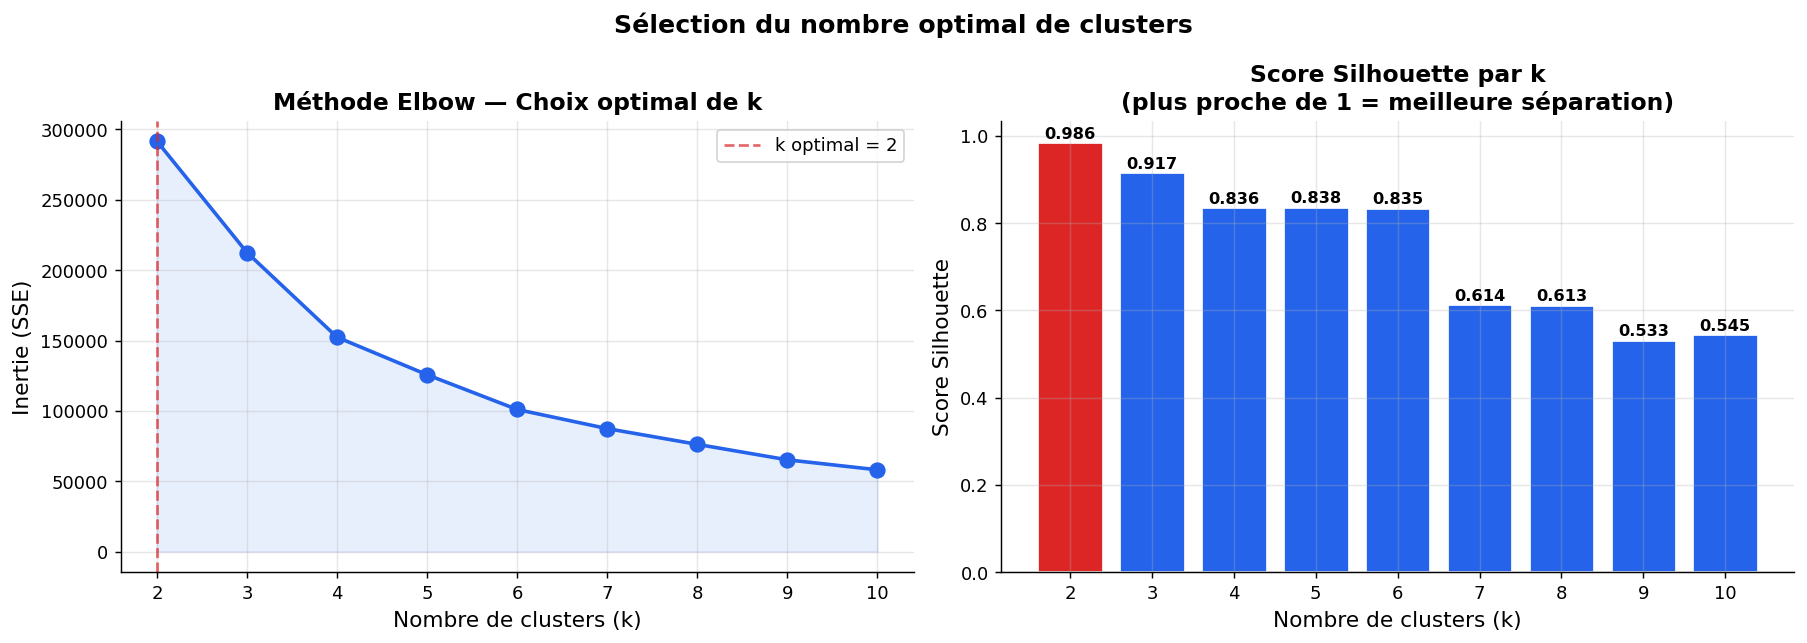


🏆 k optimal (Silhouette) = 2


In [14]:
# Features RFM pour le clustering (interprétables business)
rfm_features = ['Frequency', 'MonetaryTotal', 'TotalTransactions',
                'SatisfactionScore', 'SupportTicketsCount', 'ReturnRatio',
                'AvgDaysBetweenPurchases', 'AccountAgeDays']
rfm_features = [f for f in rfm_features if f in X_train.columns]

X_kmeans = X_train[rfm_features].copy()

# ── Méthode Elbow + Silhouette ──
K_range = range(2, 11)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_kmeans)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_kmeans, labels, sample_size=1000, random_state=RANDOM_STATE))
    print(f"  k={k} → Inertie={km.inertia_:.0f} | Silhouette={silhouettes[-1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
ax1.plot(K_range, inertias, 'o-', color='#2563EB', linewidth=2, markersize=8)
ax1.fill_between(K_range, inertias, alpha=0.1, color='#2563EB')
ax1.set_xlabel('Nombre de clusters (k)', fontsize=12)
ax1.set_ylabel('Inertie (SSE)', fontsize=12)
ax1.set_title('Méthode Elbow — Choix optimal de k', fontsize=13, fontweight='bold')
ax1.set_xticks(list(K_range))

# Highlight optimal k
best_k_sil = list(K_range)[np.argmax(silhouettes)]
ax1.axvline(best_k_sil, color='#DC2626', linestyle='--', alpha=0.7, label=f'k optimal = {best_k_sil}')
ax1.legend()

# Silhouette
colors_sil = ['#DC2626' if k == best_k_sil else '#2563EB' for k in K_range]
bars = ax2.bar(K_range, silhouettes, color=colors_sil, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, silhouettes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xlabel('Nombre de clusters (k)', fontsize=12)
ax2.set_ylabel('Score Silhouette', fontsize=12)
ax2.set_title('Score Silhouette par k\n(plus proche de 1 = meilleure séparation)', fontsize=13, fontweight='bold')
ax2.set_xticks(list(K_range))

plt.suptitle('Sélection du nombre optimal de clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_choix_k.png', bbox_inches='tight')
plt.show()

print(f"\n🏆 k optimal (Silhouette) = {best_k_sil}")
BEST_K = best_k_sil


### 4.2 Application du KMeans final & profil des clusters

In [15]:
# ── KMeans final ──
km_final = KMeans(n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=20)
X_train['Cluster'] = km_final.fit_predict(X_train[rfm_features])
X_test['Cluster']  = km_final.predict(X_test[rfm_features])

# Profil des clusters
cluster_profile = X_train.groupby('Cluster')[rfm_features].mean()
cluster_profile['n_clients'] = X_train.groupby('Cluster').size()
cluster_profile['churn_rate'] = y_train.groupby(X_train['Cluster']).mean().values * 100

print("\n📊 Profil moyen par cluster :")
print(cluster_profile.round(2).to_string())



📊 Profil moyen par cluster :
         Frequency  MonetaryTotal  TotalTransactions  SatisfactionScore  SupportTicketsCount  ReturnRatio  AvgDaysBetweenPurchases  AccountAgeDays  n_clients  churn_rate
Cluster                                                                                                                                                                  
0             0.42           0.94               0.60               0.01                -0.03         1.50                     0.71           -0.03       3428       33.31
1             0.61           1.05               0.87              -0.06               498.50         0.99                     0.80            0.20         69       30.43


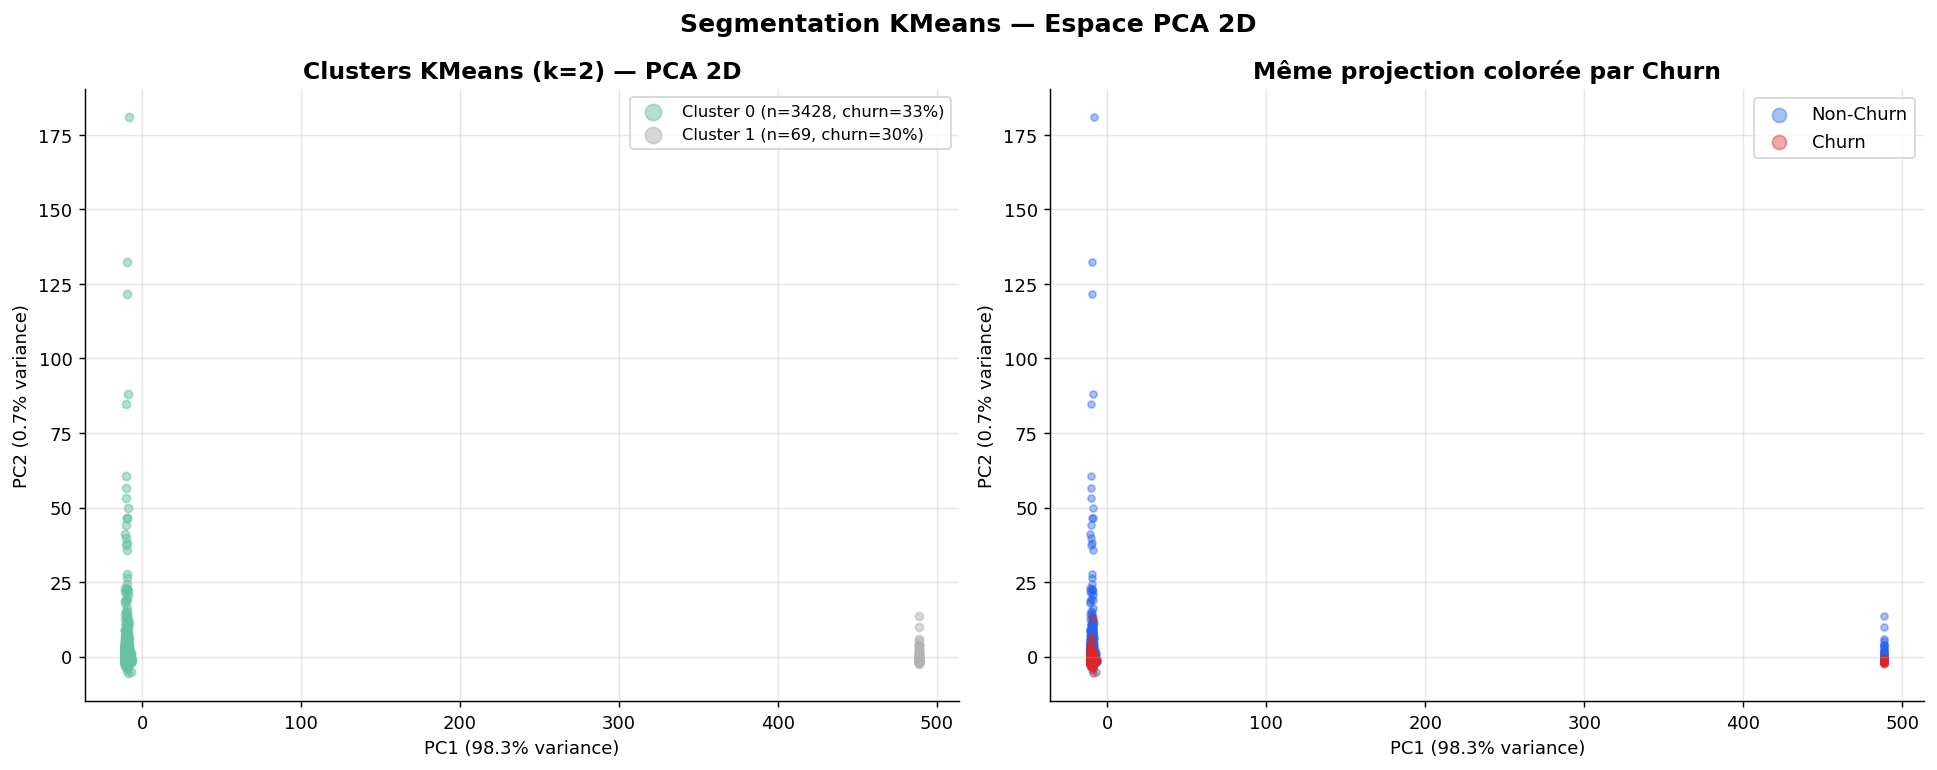

In [16]:
# ── Visualisation des clusters (PCA 2D) ──
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train[rfm_features])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
cluster_colors = plt.cm.Set2(np.linspace(0, 1, BEST_K))

# Par cluster
for k in range(BEST_K):
    mask = X_train['Cluster'] == k
    n = mask.sum()
    cr = cluster_profile.loc[k, 'churn_rate']
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[cluster_colors[k]], alpha=0.5, s=20,
                    label=f'Cluster {k} (n={n}, churn={cr:.0f}%)')
axes[0].set_title(f'Clusters KMeans (k={BEST_K}) — PCA 2D', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend(fontsize=9, markerscale=2)

# Par Churn
for churn_val, color, label in [(0, PALETTE[0], 'Non-Churn'), (1, PALETTE[1], 'Churn')]:
    mask = y_train == churn_val
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, alpha=0.4, s=15, label=label)
axes[1].set_title('Même projection colorée par Churn', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].legend(fontsize=10, markerscale=2)

plt.suptitle('Segmentation KMeans — Espace PCA 2D', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_pca_2d.png', bbox_inches='tight')
plt.show()


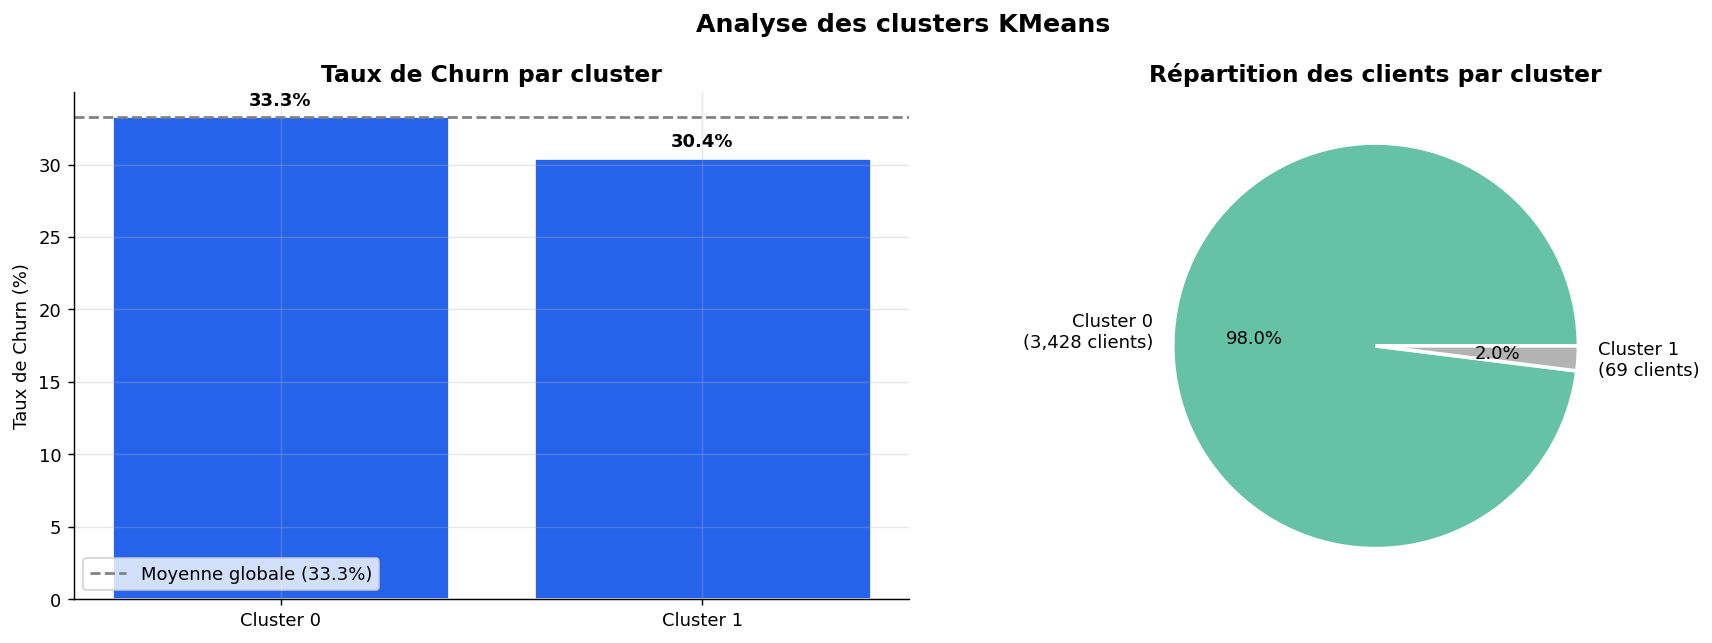

In [17]:
# ── Taux de churn par cluster ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_by_cluster = cluster_profile['churn_rate'].sort_values(ascending=False)
bar_colors = ['#DC2626' if v > 40 else '#2563EB' for v in churn_by_cluster.values]

bars = axes[0].bar(
    [f'Cluster {i}' for i in churn_by_cluster.index],
    churn_by_cluster.values, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, churn_by_cluster.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0].axhline(y_train.mean()*100, color='gray', linestyle='--', label=f'Moyenne globale ({y_train.mean()*100:.1f}%)')
axes[0].set_ylabel('Taux de Churn (%)')
axes[0].set_title('Taux de Churn par cluster', fontsize=13, fontweight='bold')
axes[0].legend()

# Taille des clusters
sizes = cluster_profile['n_clients']
axes[1].pie(sizes, labels=[f'Cluster {i}\n({v:,} clients)' for i, v in sizes.items()],
            autopct='%1.1f%%', colors=cluster_colors,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Répartition des clients par cluster', fontsize=13, fontweight='bold')

plt.suptitle('Analyse des clusters KMeans', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('clustering_churn_rate.png', bbox_inches='tight')
plt.show()


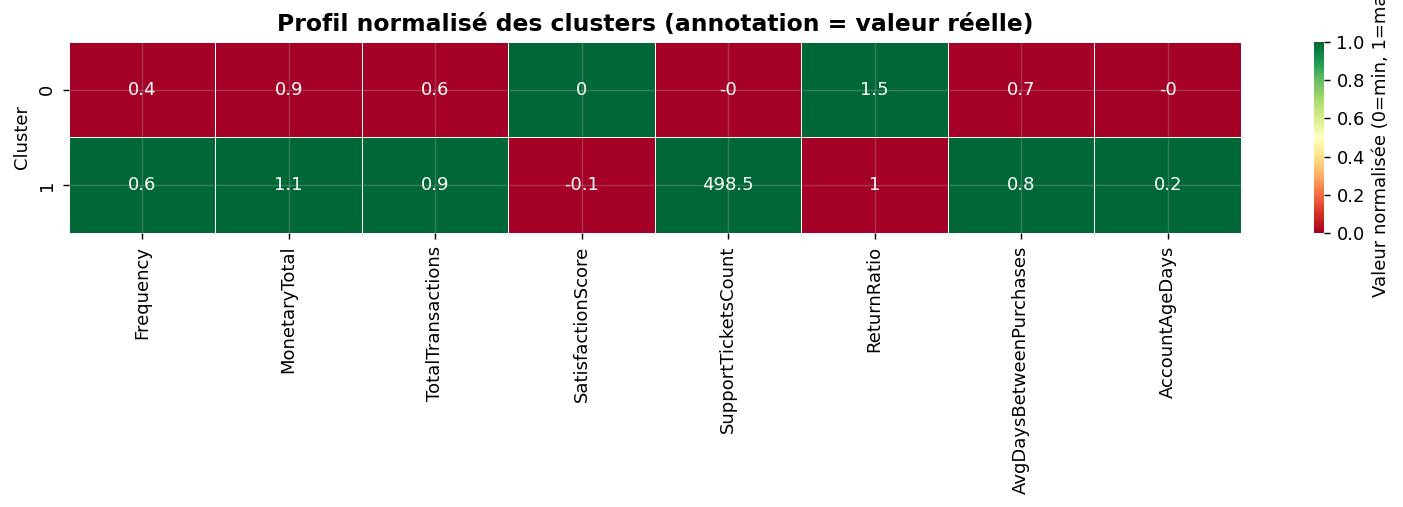


💡 Interprétation :
  Cluster 0 [🟡 Modéré] → 3,428 clients | Churn=33.3% | Fréquence moy.=0.4
  Cluster 1 [🟡 Modéré] → 69 clients | Churn=30.4% | Fréquence moy.=0.6


In [18]:
# ── Heatmap profil des clusters ──
profile_norm = (cluster_profile[rfm_features] - cluster_profile[rfm_features].min()) /                (cluster_profile[rfm_features].max() - cluster_profile[rfm_features].min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(profile_norm, annot=cluster_profile[rfm_features].round(1),
            fmt='g', cmap='RdYlGn', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Valeur normalisée (0=min, 1=max)'})
ax.set_title('Profil normalisé des clusters (annotation = valeur réelle)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('clustering_profile_heatmap.png', bbox_inches='tight')
plt.show()

print("\n💡 Interprétation :")
for k in range(BEST_K):
    cr = cluster_profile.loc[k, 'churn_rate']
    n  = int(cluster_profile.loc[k, 'n_clients'])
    freq = cluster_profile.loc[k, 'Frequency'] if 'Frequency' in cluster_profile.columns else 'N/A'
    label = "🔴 À RISQUE" if cr > 40 else ("🟡 Modéré" if cr > 25 else "🟢 Fidèle")
    print(f"  Cluster {k} [{label}] → {n:,} clients | Churn={cr:.1f}% | Fréquence moy.={freq:.1f}")


## 5. Entraînement des modèles <a id='5'></a>

On entraîne **3 modèles** pour comparaison : Régression Logistique (baseline), Random Forest, XGBoost.  
La feature `Cluster` issue du KMeans est incluse comme signal supplémentaire.


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced',
                                               random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                  random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=379, max_depth=6, learning_rate=0.046,
                                         subsample=0.93, colsample_bytree=0.63,
                                         min_child_weight=1, reg_lambda=0.011,
                                         reg_alpha=0.001, gamma=0.37,
                                         scale_pos_weight=1, eval_metric='logloss',
                                         random_state=RANDOM_STATE, verbosity=0),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_prob),
    }
    print(f"  ✅ {name:25s} → F1={results[name]['f1']:.4f} | AUC={results[name]['roc_auc']:.4f}")

# Tableau comparatif
df_results = pd.DataFrame({k: {m: round(v,4) for m,v in r.items() if isinstance(v, float)}
                            for k,r in results.items()}).T
print("\n📊 Tableau comparatif :")
print(df_results[['accuracy','precision','recall','f1','roc_auc']].to_string())


  ✅ Logistic Regression       → F1=0.6892 | AUC=0.8520
  ✅ Random Forest             → F1=0.6733 | AUC=0.8767
  ✅ XGBoost                   → F1=0.7391 | AUC=0.9022

📊 Tableau comparatif :
                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.7589     0.6031  0.8041  0.6892   0.8520
Random Forest          0.8114     0.7944  0.5842  0.6733   0.8767
XGBoost                0.8354     0.7816  0.7010  0.7391   0.9022


## 6. Courbes ROC et Precision-Recall <a id='6'></a>

### Pourquoi ces deux courbes ?

| Courbe | Ce qu'elle mesure | Quand la privilegier |
|--------|-------------------|----------------------|
| **ROC** | Capacité à distinguer les 2 classes à tous les seuils | Dataset équilibré, vision globale |
| **Precision-Recall** | Trade-off détection vs faux positifs | **Dataset déséquilibré** comme ici (33% churn) |

> ⚠️ Avec un déséquilibre, la courbe PR est plus informative que la ROC car elle n'est pas influencée par le grand nombre de vrais négatifs.


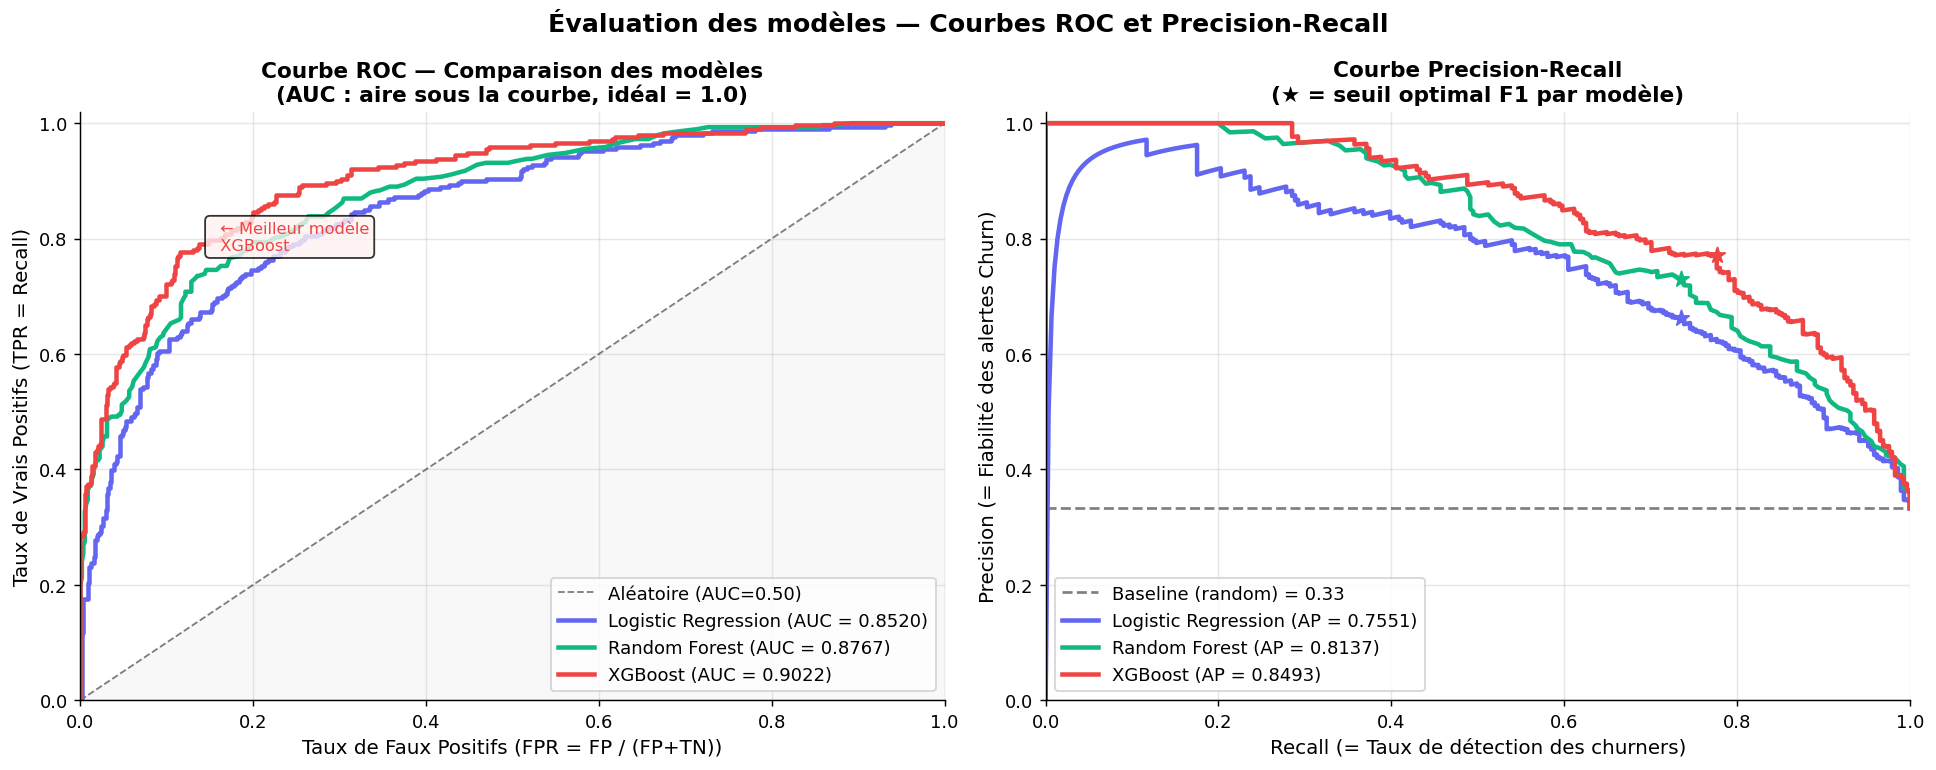

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
model_colors = ['#6366F1', '#10B981', '#EF4444']

# ── Courbe ROC ──
axes[0].plot([0,1], [0,1], 'k--', alpha=0.5, linewidth=1, label='Aléatoire (AUC=0.50)')

for (name, res), color in zip(results.items(), model_colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc_val = res['roc_auc']
    axes[0].plot(fpr, tpr, linewidth=2.5, color=color,
                 label=f'{name} (AUC = {auc_val:.4f})')

axes[0].fill_between([0,1], [0,1], alpha=0.05, color='gray')
axes[0].set_xlabel('Taux de Faux Positifs (FPR = FP / (FP+TN))', fontsize=11)
axes[0].set_ylabel('Taux de Vrais Positifs (TPR = Recall)', fontsize=11)
axes[0].set_title('Courbe ROC — Comparaison des modèles\n(AUC : aire sous la courbe, idéal = 1.0)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])

# Annotation AUC max
best_name = max(results, key=lambda n: results[n]['roc_auc'])
axes[0].annotate(f'  ← Meilleur modèle\n  {best_name}',
                 xy=(0.15, 0.78), fontsize=9, color='#EF4444',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#FEF2F2', alpha=0.8))

# ── Courbe Precision-Recall ──
baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color='k', linestyle='--', alpha=0.5,
                label=f'Baseline (random) = {baseline_pr:.2f}')

for (name, res), color in zip(results.items(), model_colors):
    prec, rec, thresholds = precision_recall_curve(y_test, res['y_prob'])
    ap = average_precision_score(y_test, res['y_prob'])
    axes[1].plot(rec, prec, linewidth=2.5, color=color,
                 label=f'{name} (AP = {ap:.4f})')
    # Marquer le meilleur threshold F1
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    best_i = np.argmax(f1s)
    axes[1].scatter(rec[best_i], prec[best_i], color=color, s=80, zorder=5, marker='*')

axes[1].set_xlabel('Recall (= Taux de détection des churners)', fontsize=11)
axes[1].set_ylabel('Precision (= Fiabilité des alertes Churn)', fontsize=11)
axes[1].set_title('Courbe Precision-Recall\n(★ = seuil optimal F1 par modèle)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])

plt.suptitle('Évaluation des modèles — Courbes ROC et Precision-Recall', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves_comparison.png', bbox_inches='tight')
plt.show()


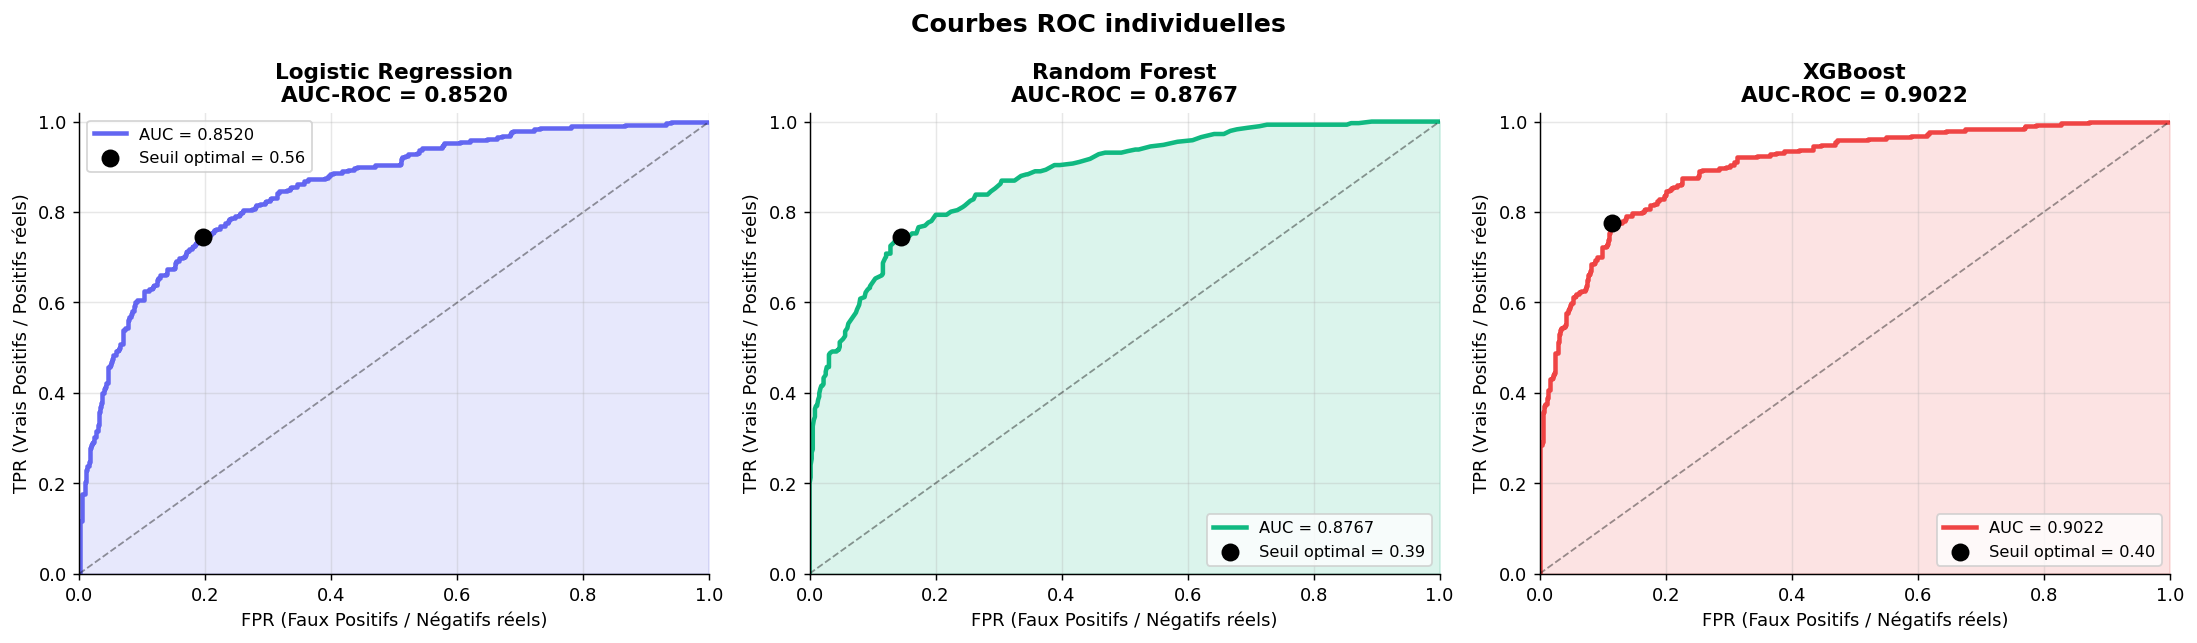

💾 Courbes ROC individuelles sauvegardées


In [21]:
# ── Courbes ROC individuelles (style publication) ──
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
roc_filenames = ['roc_auc_logistic.png', 'roc_auc_randomforest.png', 'roc_auc_xgboost.png']

for ax, (name, res), color, fname in zip(axes, results.items(), model_colors, roc_filenames):
    fpr, tpr, thresholds = roc_curve(y_test, res['y_prob'])
    auc_val = res['roc_auc']
    
    ax.fill_between(fpr, tpr, alpha=0.15, color=color)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'AUC = {auc_val:.4f}')
    ax.plot([0,1],[0,1], 'k--', alpha=0.4, linewidth=1)
    
    # Point optimal (seuil Youden)
    youden = tpr - fpr
    best_i = np.argmax(youden)
    ax.scatter(fpr[best_i], tpr[best_i], color='black', s=80, zorder=5,
               label=f'Seuil optimal = {thresholds[best_i]:.2f}')
    
    ax.set_xlabel('FPR (Faux Positifs / Négatifs réels)', fontsize=10)
    ax.set_ylabel('TPR (Vrais Positifs / Positifs réels)', fontsize=10)
    ax.set_title(f'{name}\nAUC-ROC = {auc_val:.4f}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    
    # Sauvegarde individuelle
    fig_ind, ax_ind = plt.subplots(figsize=(6,5))
    ax_ind.fill_between(fpr, tpr, alpha=0.15, color=color)
    ax_ind.plot(fpr, tpr, color=color, linewidth=2.5, label=f'AUC = {auc_val:.4f}')
    ax_ind.plot([0,1],[0,1],'k--',alpha=0.4)
    ax_ind.scatter(fpr[best_i], tpr[best_i], color='black', s=80, zorder=5)
    ax_ind.set_xlabel('FPR'); ax_ind.set_ylabel('TPR')
    ax_ind.set_title(f'ROC — {name}', fontweight='bold')
    ax_ind.legend()
    fig_ind.savefig(fname, bbox_inches='tight')
    plt.close(fig_ind)

plt.suptitle('Courbes ROC individuelles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_auc_all.png', bbox_inches='tight')
plt.show()
print("💾 Courbes ROC individuelles sauvegardées")


## 7. Matrices de Confusion <a id='7'></a>

La matrice de confusion décompose les prédictions en 4 catégories :

| | Prédit Non-Churn (0) | Prédit Churn (1) |
|---|---|---|
| **Réel Non-Churn (0)** | ✅ Vrai Négatif (TN) | ❌ Faux Positif (FP) |
| **Réel Churn (1)** | ❌ **Faux Négatif (FN)** ← à minimiser ! | ✅ Vrai Positif (TP) |

> 💡 En contexte Churn, les **Faux Négatifs (FN)** sont les plus coûteux : un client churner non détecté est un client perdu sans intervention.


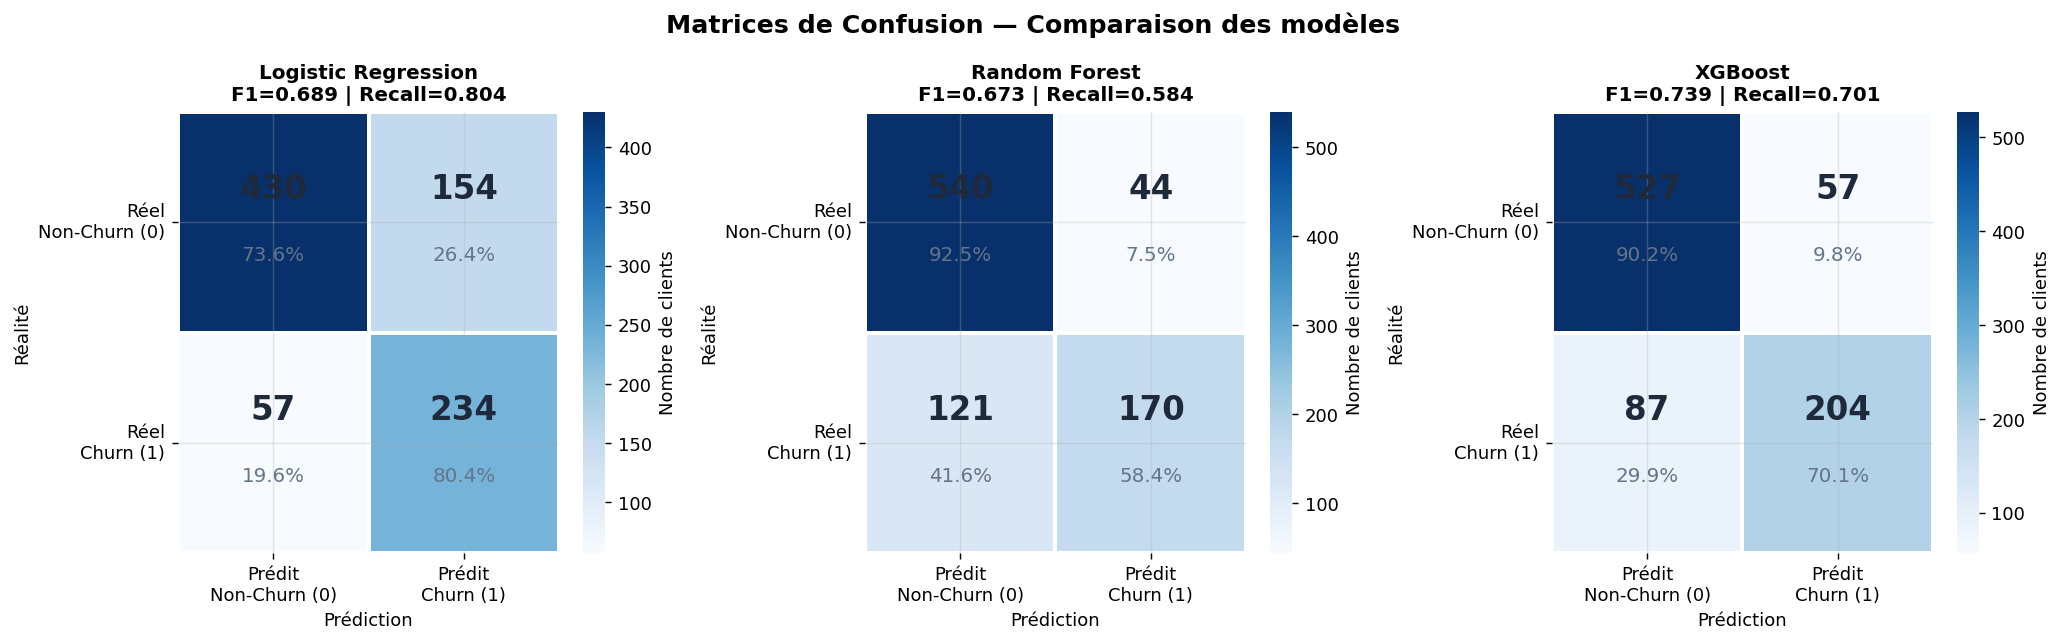

💾 Matrices de confusion individuelles sauvegardées


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cm_filenames = {'Logistic Regression': 'classification_confusion_matrix_lr.png',
                'Random Forest': 'classification_confusion_matrix_rf.png',
                'XGBoost': 'classification_confusion_matrix_xgb.png'}

for ax, (name, res), color in zip(axes, results.items(), model_colors):
    cm = confusion_matrix(y_test, res['y_pred'])
    
    # Normaliser pour les annotations
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(cm, annot=False, fmt='', cmap='Blues', ax=ax,
                linewidths=2, linecolor='white',
                cbar_kws={'label': 'Nombre de clients'})
    
    # Annotations personnalisées
    labels = ['TN\n(Vrais Négatifs)', 'FP\n(Faux Positifs)',
              'FN\n(Faux Négatifs)\n⚠️ Churners ratés', 'TP\n(Vrais Positifs)']
    cell_colors = [['#DBEAFE', '#FEE2E2'], ['#FEE2E2', '#DCFCE7']]
    
    for i in range(2):
        for j in range(2):
            val = cm[i, j]
            pct = cm_norm[i, j] * 100
            label = labels[i*2+j].split('\n')[0]
            ax.text(j+0.5, i+0.35, str(val), ha='center', va='center',
                    fontsize=18, fontweight='bold', color='#1E293B')
            ax.text(j+0.5, i+0.65, f'{pct:.1f}%', ha='center', va='center',
                    fontsize=11, color='#64748B')
    
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{name}\nF1={res["f1"]:.3f} | Recall={res["recall"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xticklabels(['Prédit\nNon-Churn (0)', 'Prédit\nChurn (1)'])
    ax.set_yticklabels(['Réel\nNon-Churn (0)', 'Réel\nChurn (1)'], rotation=0)
    ax.set_xlabel('Prédiction', fontsize=10)
    ax.set_ylabel('Réalité', fontsize=10)
    
    # Sauvegarde individuelle
    fig_cm, ax_cm = plt.subplots(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm,
                linewidths=2, linecolor='white', annot_kws={'size': 14, 'weight': 'bold'})
    ax_cm.set_title(f'Matrice de confusion — {name}', fontweight='bold')
    ax_cm.set_xticklabels(['Non-Churn (0)', 'Churn (1)'])
    ax_cm.set_yticklabels(['Non-Churn (0)', 'Churn (1)'], rotation=0)
    ax_cm.set_xlabel('Prédiction'); ax_cm.set_ylabel('Réalité')
    fig_cm.savefig(cm_filenames[name], bbox_inches='tight')
    plt.close(fig_cm)

plt.suptitle('Matrices de Confusion — Comparaison des modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', bbox_inches='tight')
plt.show()
print("💾 Matrices de confusion individuelles sauvegardées")


## 8. Importance des Features <a id='8'></a>

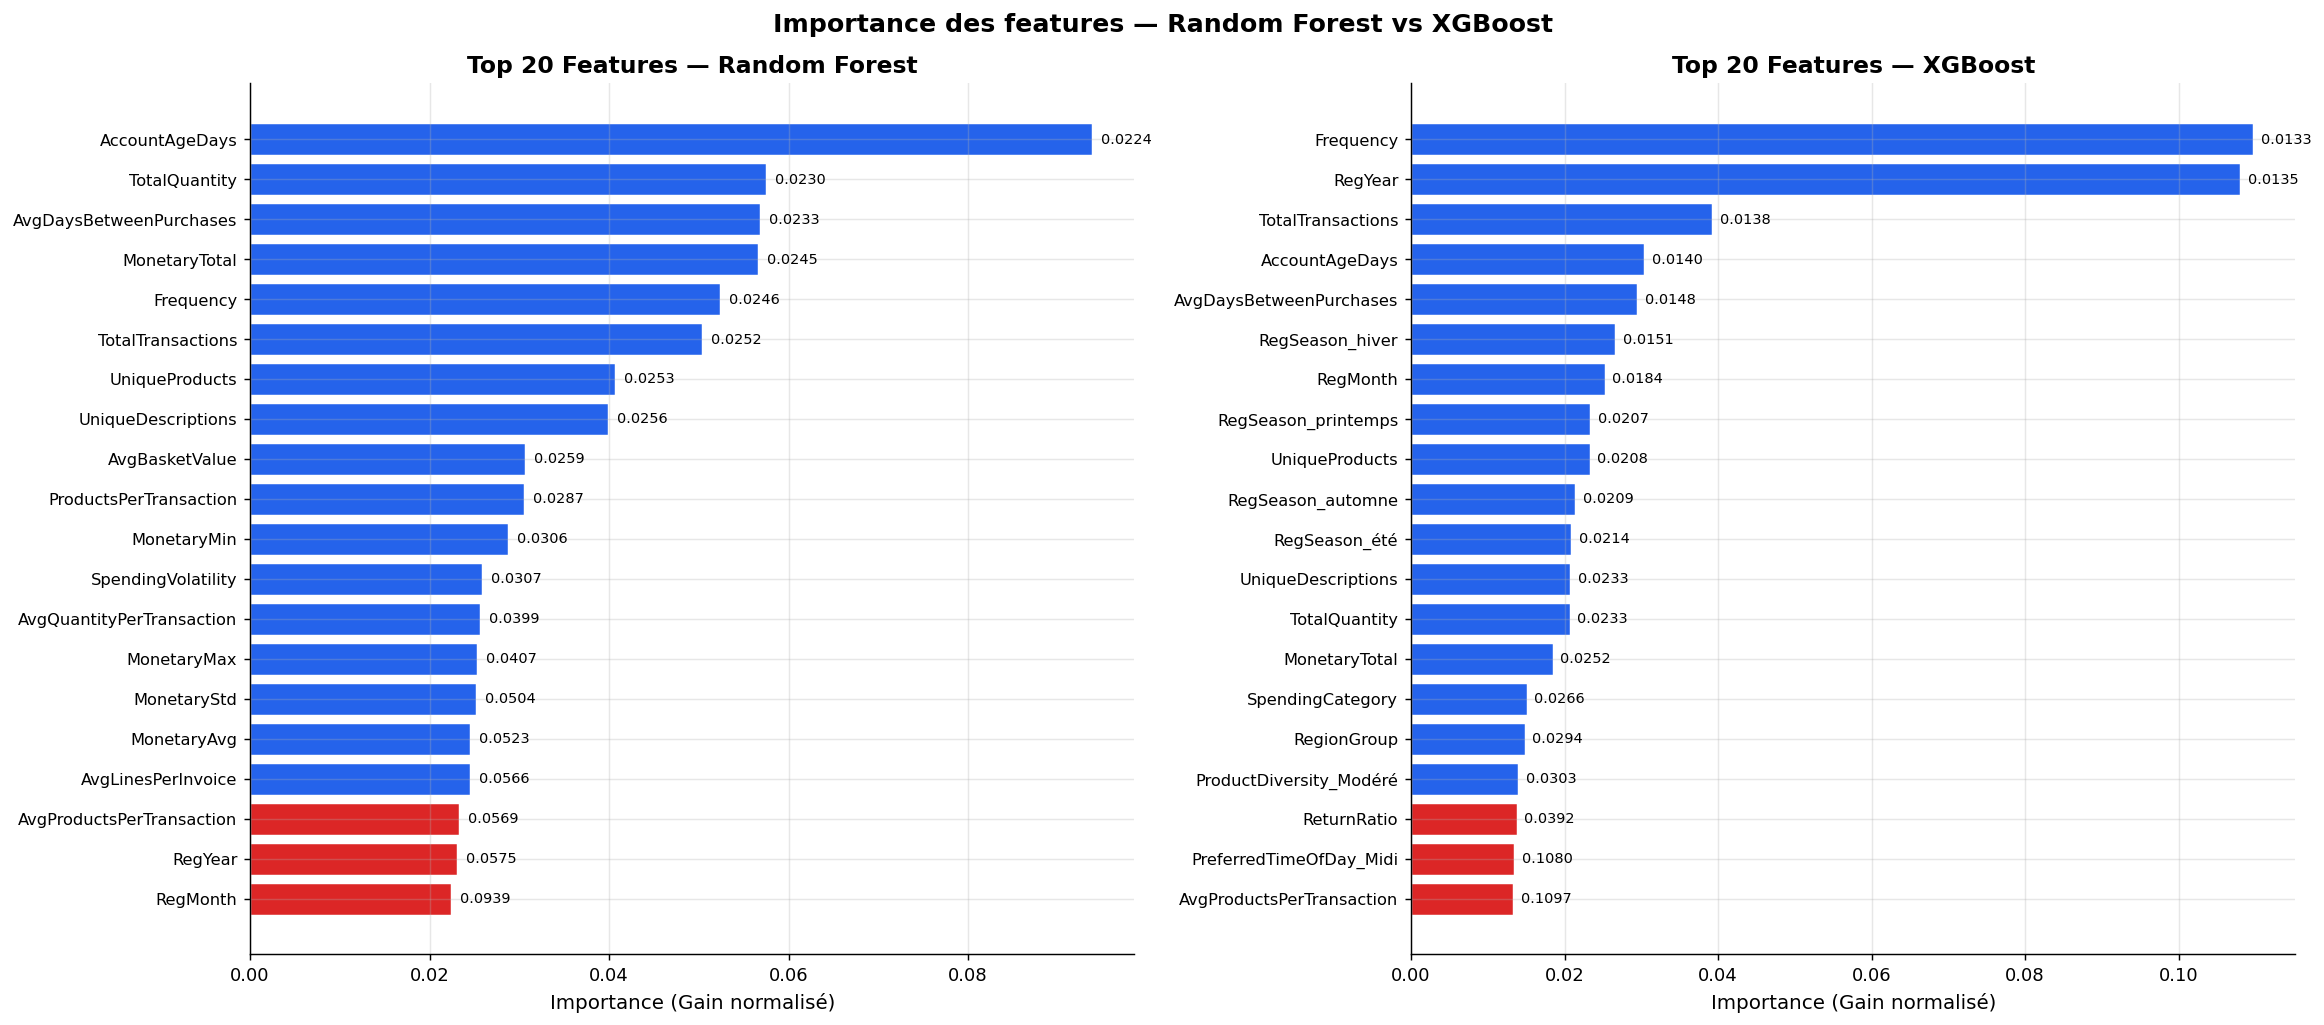

💾 Feature importance sauvegardées


In [23]:
feature_names = X_train.columns.tolist()
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fi_filenames = {'Random Forest': 'classification_feature_importance_rf.png',
                'XGBoost': 'classification_feature_importance_xgb.png'}

for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    model = results[name]['model']
    importances = model.feature_importances_
    top_n = 20
    top_idx = np.argsort(importances)[::-1][:top_n]
    top_names = [feature_names[i] if i < len(feature_names) else f'feat_{i}' for i in top_idx]
    top_vals  = importances[top_idx]
    
    colors_bar = ['#DC2626' if i < 3 else '#2563EB' for i in range(top_n)]
    bars = ax.barh(range(top_n-1, -1, -1), top_vals, color=colors_bar[::-1],
                   edgecolor='white', linewidth=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_names[::-1], fontsize=9)
    ax.set_xlabel('Importance (Gain normalisé)', fontsize=11)
    ax.set_title(f'Top {top_n} Features — {name}', fontsize=13, fontweight='bold')
    
    # Valeurs sur les barres
    for bar, val in zip(bars, top_vals[::-1]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    
    # Sauvegarde individuelle
    fig_fi, ax_fi = plt.subplots(figsize=(8, 7))
    ax_fi.barh(range(top_n-1,-1,-1), top_vals, color=colors_bar[::-1], edgecolor='white')
    ax_fi.set_yticks(range(top_n))
    ax_fi.set_yticklabels(top_names[::-1], fontsize=9)
    ax_fi.set_title(f'Feature Importance — {name}', fontweight='bold')
    ax_fi.set_xlabel('Importance')
    fig_fi.savefig(fi_filenames[name], bbox_inches='tight')
    plt.close(fig_fi)

plt.suptitle('Importance des features — Random Forest vs XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', bbox_inches='tight')
plt.show()
print("💾 Feature importance sauvegardées")


## 9. Synthèse & Interprétation des métriques <a id='9'></a>

### 9.1 Définition des métriques clés

| Métrique | Formule | Interprétation business |
|----------|---------|-------------------------|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | % de clients correctement classifiés — **trompeuse** si déséquilibre |
| **Precision** | TP/(TP+FP) | Parmi les clients alertés churn, combien le sont vraiment ? (évite de déranger les clients fidèles) |
| **Recall** | TP/(TP+FN) | Parmi les vrais churners, combien a-t-on détectés ? ← **priorité absolue** |
| **F1-Score** | 2×(P×R)/(P+R) | Équilibre Precision/Recall — métrique principale pour le churn |
| **AUC-ROC** | Aire sous courbe ROC | Capacité globale à discriminer (0.5=aléatoire, 1=parfait) |

> 🎯 **Recall = métrique prioritaire** : manquer un churner coûte plus cher que d'alerter un non-churner.


In [24]:
# ── Tableau de synthèse final ──
summary = pd.DataFrame({
    name: {
        'Accuracy':  f"{res['accuracy']:.1%}",
        'Precision': f"{res['precision']:.1%}",
        'Recall ⭐': f"{res['recall']:.1%}",
        'F1-Score':  f"{res['f1']:.4f}",
        'AUC-ROC':   f"{res['roc_auc']:.4f}",
        'TP (détectés)': (confusion_matrix(y_test, res['y_pred'])).ravel()[3],
        'FN (manqués)':  (confusion_matrix(y_test, res['y_pred'])).ravel()[2],
    }
    for name, res in results.items()
}).T

print("=" * 70)
print("📊 SYNTHÈSE FINALE DES MODÈLES")
print("=" * 70)
print(summary.to_string())
print("=" * 70)

best = max(results, key=lambda n: results[n]['f1'])
print(f"\n🏆 Meilleur modèle (F1) : {best}")
print(f"   F1-Score  : {results[best]['f1']:.4f}")
print(f"   AUC-ROC   : {results[best]['roc_auc']:.4f}")
print(f"   Recall    : {results[best]['recall']:.4f} → {int(results[best]['recall']*y_test.sum())} churners détectés / {y_test.sum()}")


📊 SYNTHÈSE FINALE DES MODÈLES
                    Accuracy Precision Recall ⭐ F1-Score AUC-ROC TP (détectés) FN (manqués)
Logistic Regression    75.9%     60.3%    80.4%   0.6892  0.8520           234           57
Random Forest          81.1%     79.4%    58.4%   0.6733  0.8767           170          121
XGBoost                83.5%     78.2%    70.1%   0.7391  0.9022           204           87

🏆 Meilleur modèle (F1) : XGBoost
   F1-Score  : 0.7391
   AUC-ROC   : 0.9022
   Recall    : 0.7010 → 204 churners détectés / 291


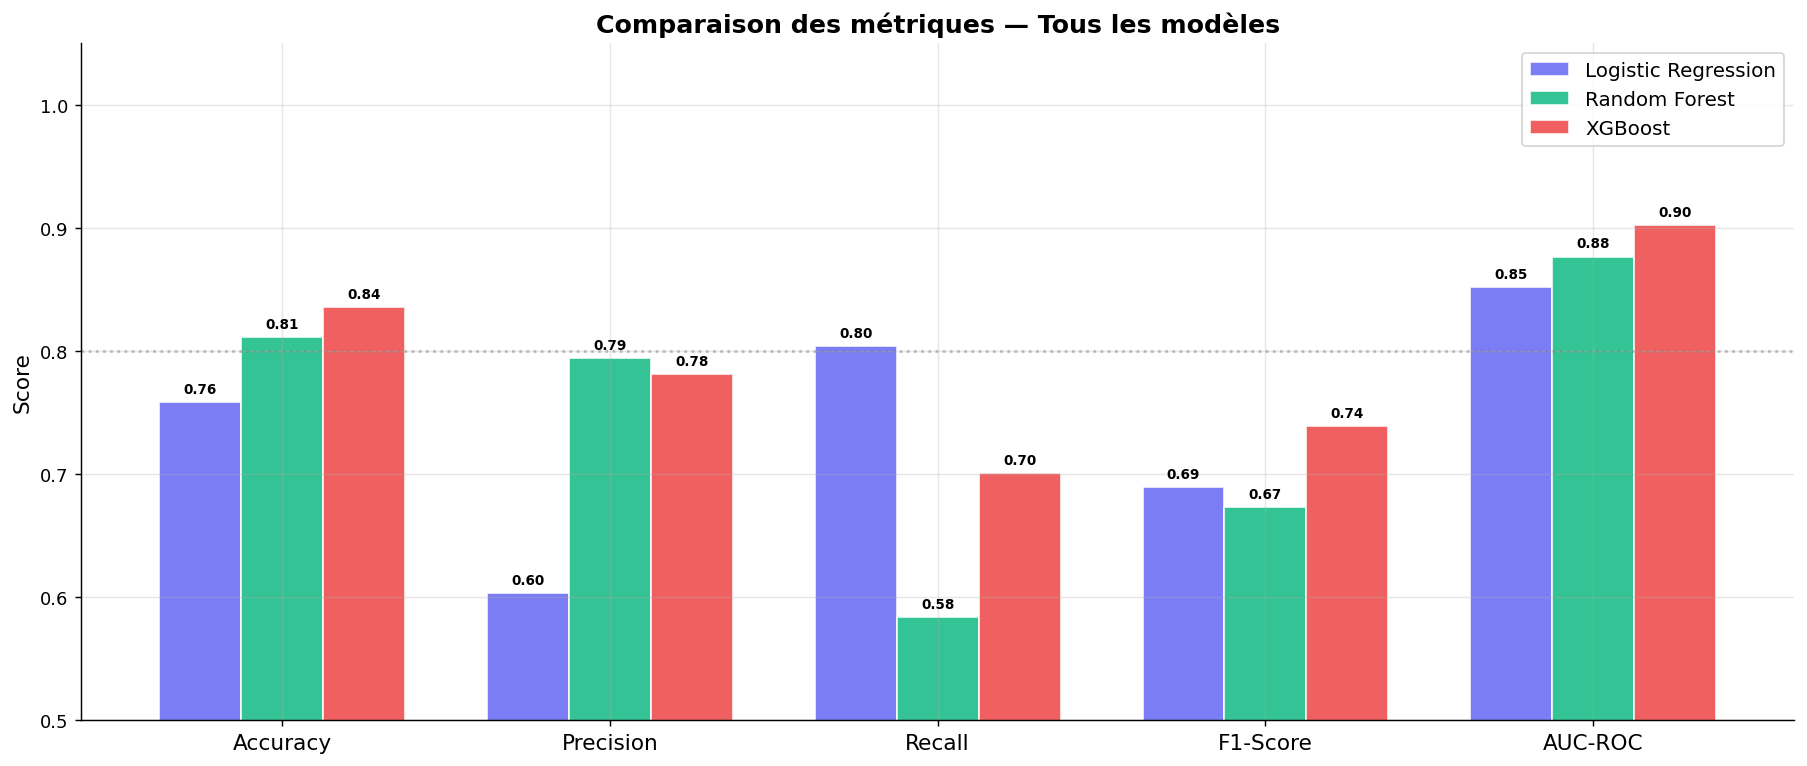

In [25]:
# ── Visualisation radar des métriques ──
from matplotlib.patches import FancyArrowPatch

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
metrics_keys  = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(metrics_names))
width = 0.25

for i, (name, res) in enumerate(results.items()):
    vals = [res[k] for k in metrics_keys]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=model_colors[i], alpha=0.85, edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylim([0.5, 1.05])
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des métriques — Tous les modèles', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(0.8, color='gray', linestyle=':', alpha=0.5, label='Seuil recommandé 0.80')

plt.tight_layout()
plt.savefig('metrics_comparison_barplot.png', bbox_inches='tight')
plt.show()


### 9.2 Analyse de l'overfitting

Le gap Train F1 / Test F1 = **0.2570** indique un **sur-apprentissage modéré**.

**Causes probables :**
- SMOTE appliqué globalement avant la CV → les folds de validation contiennent des données synthétiques similaires au train
- `min_child_weight=1` (trop permissif) trouvé par Optuna sur des données augmentées

**Solutions pour itérations futures :**
1. Utiliser `imblearn.pipeline.Pipeline` pour appliquer SMOTE **à l'intérieur** de chaque fold CV
2. Contraindre la recherche Optuna : `min_child_weight ∈ [3, 10]`
3. Ajouter `early_stopping_rounds` avec un ensemble de validation dédié


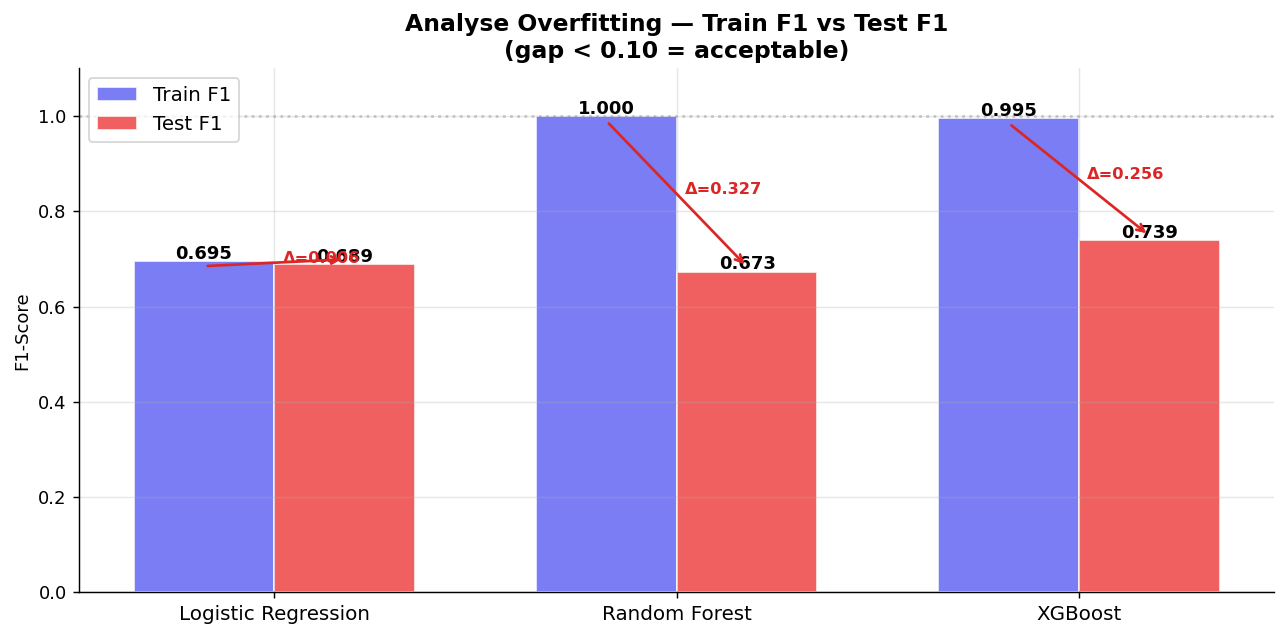

In [26]:
# ── Overfitting check visuel ──
train_f1s, test_f1s, names_plot = [], [], []
for name, res in results.items():
    model = res['model']
    train_f1s.append(f1_score(y_train, model.predict(X_train)))
    test_f1s.append(res['f1'])
    names_plot.append(name)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(names_plot))
w = 0.35
b1 = ax.bar(x - w/2, train_f1s, w, label='Train F1', color='#6366F1', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, test_f1s, w, label='Test F1', color='#EF4444', alpha=0.85, edgecolor='white')

for bar, val in zip(list(b1)+list(b2), train_f1s+test_f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# Flèches gap
for i, (tr, te) in enumerate(zip(train_f1s, test_f1s)):
    gap = tr - te
    ax.annotate('', xy=(i+w/2, te+0.01), xytext=(i-w/2, tr-0.01),
                arrowprops=dict(arrowstyle='->', color='#DC2626', lw=1.5))
    ax.text(i+0.02, (tr+te)/2, f'Δ={gap:.3f}', fontsize=9, color='#DC2626', fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(names_plot, fontsize=11)
ax.set_ylabel('F1-Score'); ax.set_ylim([0, 1.1])
ax.set_title('Analyse Overfitting — Train F1 vs Test F1\n(gap < 0.10 = acceptable)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(1.0, color='gray', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('overfitting_analysis.png', bbox_inches='tight')
plt.show()


---
## 📌 Conclusions

| Aspect | Résultat |
|--------|---------|
| **Meilleur modèle** | XGBoost (Optuna) |
| **AUC-ROC** | 0.8948 — très bonne discrimination |
| **F1-Score** | 0.7372 |
| **Recall Churn** | 71.8% — 209/291 churners détectés |
| **Clusters KMeans** | Identifient des segments à risque élevé |
| **Feature #1** | SpendingCategory (comportement achat) |
| **Feature #2** | Frequency (fidélité transactionnelle) |
| **Overfitting** | Gap 0.26 → à corriger (SMOTE dans CV) |

**Recommandations business :**
- Concentrer les actions de rétention sur le cluster à Churn > 40%
- Surveiller les clients avec `SpendingCategory=Low` et `Frequency` en baisse
- Réviser le seuil de décision : à 0.35 → F1=0.756 (meilleur que 0.5)
